# MindReader Clinical Trial Study & Pipeline Comparison Prototype

This notebook demonstrates how MindReader can convert raw clinical trial registry data into structured, normalized, weighted, and explainable study/pipeline comparisons.

The goal is not to build a chatbot yet. The goal is to prove that we can compare clinical studies and pipelines on clinically meaningful dimensions such as efficacy, safety, tolerability, patient convenience, endpoint quality, cost/access, regulatory maturity, and pipeline strength.

This notebook is designed for approval. After approval, the method can be converted into a repeatable product pipeline.


## Why This Matters

Clinical trial records are difficult to compare manually because each study may have different endpoints, populations, phases, sponsors, results availability, safety signals, and design choices.

MindReader’s value is to convert these scattered fields into structured intelligence:
- What looks clinically meaningful?
- What looks safe or risky?
- Which therapy is easier for patients?
- Which pipeline looks more mature?
- Which studies have stronger evidence?
- Where is data missing?


In [1]:
import os
import glob
import json
import math
import urllib.request
import urllib.parse
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, RobustScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 160)
sns.set_theme(style='whitegrid')


In [2]:
def find_clinical_trials_csv():
    preferred = 'clinical_trials(1).csv'
    if os.path.exists(preferred):
        return preferred

    candidates = glob.glob('*clinical_trials*.csv')
    if not candidates:
        raise FileNotFoundError('No clinical trial CSV found in current directory.')
    return candidates[0]

csv_path = find_clinical_trials_csv()
df = pd.read_csv(csv_path)

print('Loaded:', csv_path)
print('Shape:', df.shape)
display(df.head())
display(df.isna().sum().sort_values(ascending=False))


Loaded: clinical_trials.csv
Shape: (7000, 12)


,nct_id,brief_title,official_title,category,status,start_date,completion_date,sponsor,study_type,phase,enrollment,conditions
0,NCT04799925,Hyperuricemia and Diabetic Nephropathy,Effect of Treatment of Hyperuricemia on Progression of Diabetic Nephropathy in Patients With Type II Diabetes Mellitus and Stage III Chronic Kidney Disease.,Autoimmune,UNKNOWN,2021-04-15,2022-12-30,Assiut University,OBSERVATIONAL,NaN,200,"Hyperuricemia, Diabetic Nephropathies"
1,NCT05132725,Carbohydrate Counting and DASH Intervention Among Children With Diabetes and Celiac Disease.,Studying the Effect of Gluten Free Diet Alone Versus Combination of Gluten Free Diet With Either Carbohydrate Count or Dietary Approach to Reduce Hypertensi...,Autoimmune,UNKNOWN,2021-11-15,2022-11-11,University of Jordan,INTERVENTIONAL,NaN,45,"Diabetes Mellitus, Type 1, Celiac Disease in Children"
2,NCT05945576,IDMet (RaDiCo Cohort) (RaDiCo-IDMet),National Cohort on Imprinting Disorders and Their Metabolic Consequences,Autoimmune,RECRUITING,2017-03-10,2028-03,"Institut National de la Santé Et de la Recherche Médicale, France",OBSERVATIONAL,NaN,2000,"Silver Russell Syndrome, Beckwith-Wiedemann Syndrome, Transient Neonatal Diabetes Mellitus, Angelman Syndrome, Prader-Willi Syndrome, Temple Syndrome, Kagam..."
3,NCT06530940,Diagnostic Interest of the Buccal Schirmer Test in Xerostomia During Sjögren's Syndrome: XERODIAG,Diagnostic Interest of the Buccal Schirmer Test in Xerostomia During Sjögren's Syndrome: XERODIAG,Autoimmune,NOT_YET_RECRUITING,2024-08-19,2024-12-31,University Tunis El Manar,OBSERVATIONAL,NaN,180,"Sjogren's Syndrome, Xerostomia, Diagnosis"
4,NCT03715140,Crucumin Effects on the Immune System in Osteoarthritis Patients,Evaluation of the Crucumin Effects on the Cellular and Humoral Immune Systems in Osteoarthritis Patients; a Randomised Double Blind Placebo Control Clinical...,Autoimmune,UNKNOWN,2019-05-01,2020-12-30,Mashhad University of Medical Sciences,INTERVENTIONAL,PHASE3,30,Osteoarthritis


phase              3623
completion_date     229
official_title       91
start_date           40
nct_id                0
brief_title           0
category              0
status                0
sponsor               0
study_type            0
enrollment            0
conditions            0
dtype: int64

## Dataset Understanding

The broad dataset is useful for pipeline-level analysis. It contains trial identifiers, category, sponsor, phase, status, enrollment, dates, and conditions.

However, broad CSV fields are not enough for deep study comparison. To compare studies properly, we need detailed records from ClinicalTrials.gov API v2 using each NCT ID.

### Key Fields Description:
* `nct_id`: The unique identifier for the clinical trial (e.g. NCT04799925).
* `brief_title`: The short title of the study.
* `official_title`: The detailed official title of the study.
* `category`: The therapeutic area category (e.g. Oncology, Autoimmune).
* `status`: The current status of the trial (e.g. Completed, Recruiting).
* `start_date`: The official start date of the study.
* `completion_date`: The completion date of the study.
* `sponsor`: The lead organization sponsor.
* `study_type`: The nature of the study design (e.g. Interventional, Observational).
* `phase`: The phase of development (e.g. Phase 1, Phase 2, Phase 3, Phase 4).
* `enrollment`: The planned or actual sample size.
* `conditions`: The clinical conditions or diseases studied.


In [3]:
def fetch_in_depth_trial_data(nct_id, timeout=20):
    url = f'https://clinicaltrials.gov/api/v2/studies/{nct_id}'
    req = urllib.request.Request(
        url,
        headers={'User-Agent': 'MindReader-Clinical-Trial-Prototype/1.0'}
    )

    try:
        with urllib.request.urlopen(req, timeout=timeout) as response:
            return json.loads(response.read().decode('utf-8'))
    except Exception as e:
        print(f'Error fetching {nct_id}: {e}')
        return None


This API call gives us the full study record for one NCT ID, including protocol details, outcomes, design information, eligibility, sponsor details, locations, publications, and results availability where available.


In [4]:
def safe_get(d, path, default=None):
    current = d
    for key in path:
        if not isinstance(current, dict):
            return default
        current = current.get(key)
        if current is None:
            return default
    return current

def list_to_text(values, limit=None):
    if not values:
        return 'Not available in source data'
    if limit:
        values = values[:limit]
    return '; '.join([str(v) for v in values if v])

def normalize_text(value):
    if value is None:
        return ''
    return str(value).strip().lower()


In [5]:
def parse_trial_details(study_data):
    if not study_data:
        return None

    protocol = study_data.get('protocolSection', {})
    results_section = study_data.get('resultsSection', {})

    id_module = protocol.get('identificationModule', {})
    status_module = protocol.get('statusModule', {})
    sponsor_module = protocol.get('sponsorCollaboratorsModule', {})
    design_module = protocol.get('designModule', {})
    conditions_module = protocol.get('conditionsModule', {})
    arms_module = protocol.get('armsInterventionsModule', {})
    outcomes_module = protocol.get('outcomesModule', {})
    eligibility_module = protocol.get('eligibilityModule', {})
    contacts_locations_module = protocol.get('contactsLocationsModule', {})
    more_info_module = protocol.get('moreInfoModule', {})

    nct_id = id_module.get('nctId', '')
    brief_title = id_module.get('briefTitle', '')
    official_title = id_module.get('officialTitle', '')

    status = status_module.get('overallStatus', '')
    start_date = safe_get(status_module, ['startDateStruct', 'date'], '')
    primary_completion_date = safe_get(status_module, ['primaryCompletionDateStruct', 'date'], '')
    completion_date = safe_get(status_module, ['completionDateStruct', 'date'], '')

    lead_sponsor = safe_get(sponsor_module, ['leadSponsor', 'name'], '')
    sponsor_class = safe_get(sponsor_module, ['leadSponsor', 'class'], '')
    collaborators = [
        c.get('name', '') for c in sponsor_module.get('collaborators', [])
    ]

    study_type = design_module.get('studyType', '')
    phases = design_module.get('phases', [])
    phase = phases[0] if phases else 'NA'
    enrollment_count = safe_get(design_module, ['enrollmentInfo', 'count'], np.nan)
    enrollment_type = safe_get(design_module, ['enrollmentInfo', 'type'], '')

    design_info = design_module.get('designInfo', {})
    allocation = design_info.get('allocation', '')
    intervention_model = design_info.get('interventionModel', '')
    masking = design_info.get('maskingInfo', {}).get('masking', '')
    primary_purpose = design_info.get('primaryPurpose', '')
    observational_model = design_info.get('observationalModel', '')
    time_perspective = design_info.get('timePerspective', '')

    conditions = conditions_module.get('conditions', [])
    keywords = conditions_module.get('keywords', [])

    interventions = arms_module.get('interventions', [])
    intervention_names = [i.get('name', '') for i in interventions]
    intervention_types = [i.get('type', '') for i in interventions]
    intervention_descriptions = [i.get('description', '') for i in interventions if i.get('description')]

    arm_groups = arms_module.get('armGroups', [])
    number_of_arms = len(arm_groups)

    primary_outcomes = []
    for item in outcomes_module.get('primaryOutcomes', []):
        primary_outcomes.append({
            'measure': item.get('measure', ''),
            'description': item.get('description', ''),
            'time_frame': item.get('timeFrame', ''),
            'endpoint_type': 'primary'
        })

    secondary_outcomes = []
    for item in outcomes_module.get('secondaryOutcomes', []):
        secondary_outcomes.append({
            'measure': item.get('measure', ''),
            'description': item.get('description', ''),
            'time_frame': item.get('timeFrame', ''),
            'endpoint_type': 'secondary'
        })

    other_outcomes = []
    for item in outcomes_module.get('otherOutcomes', []):
        other_outcomes.append({
            'measure': item.get('measure', ''),
            'description': item.get('description', ''),
            'time_frame': item.get('timeFrame', ''),
            'endpoint_type': 'other'
        })

    eligibility = eligibility_module.get('eligibilityCriteria', '')
    minimum_age = eligibility_module.get('minimumAge', '')
    maximum_age = eligibility_module.get('maximumAge', '')
    sex = eligibility_module.get('sex', '')
    healthy_volunteers = eligibility_module.get('healthyVolunteers', '')

    locations = contacts_locations_module.get('locations', [])
    countries = sorted(list(set([
        loc.get('country', '') for loc in locations if loc.get('country')
    ])))
    facility_count = len(locations)

    publications = []
    for pub in more_info_module.get('publications', []):
        publications.append({
            'pmid': pub.get('pmid', ''),
            'reference': pub.get('reference', '')
        })

    has_results = bool(study_data.get('hasResults', False) or results_section)

    return {
        'nct_id': nct_id,
        'brief_title': brief_title,
        'official_title': official_title,
        'status': status,
        'start_date': start_date,
        'primary_completion_date': primary_completion_date,
        'completion_date': completion_date,
        'lead_sponsor': lead_sponsor,
        'sponsor_class': sponsor_class,
        'collaborators': collaborators,
        'study_type': study_type,
        'phase': phase,
        'enrollment_count': enrollment_count,
        'enrollment_type': enrollment_type,
        'conditions': conditions,
        'keywords': keywords,
        'intervention_names': intervention_names,
        'intervention_types': intervention_types,
        'intervention_descriptions': intervention_descriptions,
        'allocation': allocation,
        'intervention_model': intervention_model,
        'masking': masking,
        'primary_purpose': primary_purpose,
        'observational_model': observational_model,
        'time_perspective': time_perspective,
        'number_of_arms': number_of_arms,
        'primary_outcomes': primary_outcomes,
        'secondary_outcomes': secondary_outcomes,
        'other_outcomes': other_outcomes,
        'minimum_age': minimum_age,
        'maximum_age': maximum_age,
        'sex': sex,
        'healthy_volunteers': healthy_volunteers,
        'eligibility_criteria': eligibility,
        'countries': countries,
        'facility_count': facility_count,
        'publications': publications,
        'publication_count': len(publications),
        'has_results': has_results,
        'raw_results_available': bool(results_section),
    }


In [6]:
def validate_study_identity(
    parsed_study,
    expected_condition=None,
    expected_intervention=None,
    expected_sponsor=None,
    expected_keywords=None
):
    warnings = []
    failed_checks = []

    if not parsed_study:
        return {
            'is_valid': False,
            'confidence': 'low',
            'warnings': ['Study could not be parsed.'],
            'failed_checks': ['parse_failed']
        }

    searchable_text = ' '.join([
        parsed_study.get('brief_title', ''),
        parsed_study.get('official_title', ''),
        ' '.join(parsed_study.get('conditions', [])),
        ' '.join(parsed_study.get('intervention_names', [])),
        parsed_study.get('lead_sponsor', '')
    ]).lower()

    if not parsed_study.get('nct_id'):
        failed_checks.append('missing_nct_id')
        warnings.append('Missing NCT ID.')

    if not parsed_study.get('brief_title'):
        failed_checks.append('missing_title')
        warnings.append('Missing brief title.')

    if expected_condition:
        if expected_condition.lower() not in searchable_text:
            failed_checks.append('condition_mismatch')
            warnings.append(f'Expected condition not found: {expected_condition}')

    if expected_intervention:
        if expected_intervention.lower() not in searchable_text:
            failed_checks.append('intervention_mismatch')
            warnings.append(f'Expected intervention not found: {expected_intervention}')

    if expected_sponsor:
        if expected_sponsor.lower() not in searchable_text:
            failed_checks.append('sponsor_mismatch')
            warnings.append(f'Expected sponsor not found: {expected_sponsor}')

    if expected_keywords:
        missing_keywords = []
        for kw in expected_keywords:
            if kw.lower() not in searchable_text:
                missing_keywords.append(kw)

        if missing_keywords:
            failed_checks.append('keyword_mismatch')
            warnings.append(f'Missing expected keywords: {missing_keywords}')

    is_valid = len(failed_checks) == 0

    if is_valid:
        confidence = 'high'
    elif len(failed_checks) <= 2:
        confidence = 'medium'
    else:
        confidence = 'low'

    return {
        'is_valid': is_valid,
        'confidence': confidence,
        'warnings': warnings,
        'failed_checks': failed_checks
    }


Clinical trial comparison can become misleading if the wrong NCT ID is used. This validation layer checks whether the fetched study matches the expected disease area, intervention, sponsor, or keywords before generating comparison insights.


In [7]:
def classify_disease_area(conditions):
    text = ' '.join(conditions).lower()
    cond_set = {c.lower().strip() for c in conditions}

    if 'ra' in cond_set or 'rheumatoid arthritis' in text or 'sjogren\'s syndrome' in text:
        return 'Autoimmune / Immunology'

    oncology_terms = ['cancer', 'tumor', 'tumour', 'carcinoma', 'lymphoma', 'leukemia', 'melanoma', 'neoplasm', 'sarcoma', 'oncolog']
    autoimmune_terms = ['autoimmune', 'arthritis', 'lupus', 'psoriasis', 'crohn', 'colitis', 'sclerosis', 'celiac', 'immunolog']
    neuro_terms = ['alzheimer', 'parkinson', 'epilepsy', 'migraine', 'dementia', 'neuropathy', 'stroke', 'neurolog']
    cardio_terms = ['heart', 'cardiac', 'hypertension', 'coronary', 'myocardial', 'atrial', 'cardiovascular']
    metabolic_terms = ['obesity', 'diabetes', 'diabetic', 'metabolic', 'cholesterol', 'dyslipidemia', 'fatty liver', 'hyperuricemia', 'nephropathy', 'kidney']
    infectious_terms = ['infection', 'viral', 'bacterial', 'hiv', 'covid', 'influenza', 'hepatitis']
    rare_terms = ['rare', 'orphan', 'duchenne', 'cystic fibrosis', 'sickle cell']

    if any(t in text for t in oncology_terms):
        return 'Oncology'
    if any(t in text for t in autoimmune_terms):
        return 'Autoimmune / Immunology'
    if any(t in text for t in neuro_terms):
        return 'Neurology'
    if any(t in text for t in cardio_terms):
        return 'Cardiology'
    if any(t in text for t in metabolic_terms):
        return 'Metabolic'
    if any(t in text for t in infectious_terms):
        return 'Infectious Disease'
    if any(t in text for t in rare_terms):
        return 'Rare Disease'
    return 'Other'

def classify_modality(intervention_names, intervention_types):
    text = ' '.join(intervention_names + intervention_types).lower()

    if 'biological' in text or 'antibody' in text or 'mab' in text:
        return 'Biologic / Antibody'
    if 'drug' in text or 'tablet' in text or 'capsule' in text:
        return 'Drug / Small Molecule'
    if 'cell' in text or 'car-t' in text or 't cell' in text:
        return 'Cell Therapy'
    if 'gene' in text or 'rna' in text or 'sirna' in text:
        return 'Gene / RNA Therapy'
    if 'device' in text:
        return 'Device'
    if 'procedure' in text or 'surgery' in text:
        return 'Procedure'
    if 'dietary' in text or 'behavioral' in text:
        return 'Lifestyle / Behavioral'
    return 'Other / Unknown'


In [8]:
def classify_endpoint_type(text):
    text = normalize_text(text)

    hard_clinical = [
        'overall survival', 'mortality', 'death', 'hospitalization',
        'major adverse', 'relapse', 'remission', 'flare', 'disability'
    ]

    oncology_intermediate = [
        'progression-free survival', 'pfs', 'objective response', 'orr',
        'complete response', 'partial response', 'disease-free survival', 'dfs'
    ]

    surrogate = [
        'biomarker', 'hba1c', 'egfr', 'ldl', 'blood pressure',
        'acr20', 'acr50', 'acr70', 'pasi', 'viral load', 'tumor size'
    ]

    safety = [
        'adverse event', 'serious adverse', 'toxicity', 'safety',
        'tolerability', 'dose limiting', 'side effect'
    ]

    qol = [
        'quality of life', 'qol', 'patient reported', 'fatigue',
        'pain', 'symptom', 'function'
    ]

    if any(t in text for t in hard_clinical):
        return 'Hard clinical endpoint'
    if any(t in text for t in oncology_intermediate):
        return 'Intermediate oncology endpoint'
    if any(t in text for t in surrogate):
        return 'Surrogate / biomarker endpoint'
    if any(t in text for t in safety):
        return 'Safety endpoint'
    if any(t in text for t in qol):
        return 'Patient-reported / quality-of-life endpoint'
    if not text:
        return 'Endpoint not clearly available'
    return 'Other endpoint'

def endpoint_strength_value(endpoint_type):
    mapping = {
        'Hard clinical endpoint': 1.00,
        'Patient-reported / quality-of-life endpoint': 0.85,
        'Intermediate oncology endpoint': 0.75,
        'Surrogate / biomarker endpoint': 0.60,
        'Safety endpoint': 0.55,
        'Other endpoint': 0.40,
        'Endpoint not clearly available': 0.10,
    }
    return mapping.get(endpoint_type, 0.40)


In [9]:
def phase_to_numeric(phase):
    text = normalize_text(phase).replace(' ', '').replace('_', '')

    if 'phase4' in text:
        return 4
    if 'phase3' in text:
        return 3
    if 'phase2' in text and 'phase3' in text:
        return 2.5
    if 'phase2' in text:
        return 2
    if 'phase1' in text and 'phase2' in text:
        return 1.5
    if 'earlyphase1' in text:
        return 0.5
    if 'phase1' in text:
        return 1
    return 0

def extract_raw_scoring_factors(study):
    primary_outcomes = study.get('primary_outcomes', [])
    secondary_outcomes = study.get('secondary_outcomes', [])

    primary_text = ' '.join([
        f"{x.get('measure', '')} {x.get('description', '')} {x.get('time_frame', '')}"
        for x in primary_outcomes
    ])

    all_endpoint_text = ' '.join([
        f"{x.get('measure', '')} {x.get('description', '')} {x.get('time_frame', '')}"
        for x in primary_outcomes + secondary_outcomes
    ])

    endpoint_type = classify_endpoint_type(primary_text)
    endpoint_strength = endpoint_strength_value(endpoint_type)

    status_text = normalize_text(study.get('status', ''))
    allocation_text = normalize_text(study.get('allocation', ''))
    masking_text = normalize_text(study.get('masking', ''))
    intervention_model_text = normalize_text(study.get('intervention_model', ''))
    study_type_text = normalize_text(study.get('study_type', ''))

    enrollment = study.get('enrollment_count')
    try:
        enrollment = float(enrollment)
    except Exception:
        enrollment = np.nan

    has_results = 1 if study.get('has_results') else 0
    has_publications = 1 if study.get('publication_count', 0) > 0 else 0
    publication_count = study.get('publication_count', 0)

    is_completed = 1 if 'completed' in status_text else 0
    is_active = 1 if any(x in status_text for x in ['recruiting', 'active', 'not yet recruiting']) else 0
    is_negative_status = 1 if any(x in status_text for x in ['terminated', 'withdrawn', 'suspended']) else 0

    is_randomized = 1 if 'random' in allocation_text else 0
    has_masking = 1 if masking_text and masking_text not in ['none', 'open label'] else 0
    has_control_signal = 1 if any(x in intervention_model_text + ' ' + all_endpoint_text.lower() for x in ['placebo', 'control', 'comparator', 'standard of care']) else 0
    is_interventional = 1 if 'interventional' in study_type_text else 0

    primary_endpoint_count = len(primary_outcomes)
    secondary_endpoint_count = len(secondary_outcomes)
    has_clear_primary_endpoint = 1 if primary_endpoint_count > 0 and primary_text.strip() else 0

    has_primary_timeframe = 0
    for endpoint in primary_outcomes:
        if endpoint.get('time_frame'):
            has_primary_timeframe = 1
            break

    facility_count = study.get('facility_count', 0)
    country_count = len(study.get('countries', []))

    disease_area = classify_disease_area(study.get('conditions', []))
    modality = classify_modality(study.get('intervention_names', []), study.get('intervention_types', []))

    route_text = ' '.join(
        study.get('intervention_names', []) +
        study.get('intervention_types', []) +
        study.get('intervention_descriptions', [])
    ).lower()

    oral_signal = 1 if any(x in route_text for x in ['oral', 'tablet', 'capsule', 'pill']) else 0
    injection_signal = 1 if any(x in route_text for x in ['injection', 'subcutaneous', 'intramuscular']) else 0
    infusion_signal = 1 if any(x in route_text for x in ['infusion', 'intravenous', 'iv']) else 0

    convenience_score_raw = 0.5
    if oral_signal:
        convenience_score_raw = 1.0
    elif injection_signal:
        convenience_score_raw = 0.7
    elif infusion_signal:
        convenience_score_raw = 0.35

    safety_endpoint_signal = 1 if any(
        x in all_endpoint_text.lower()
        for x in ['adverse event', 'serious adverse', 'safety', 'toxicity', 'tolerability']
    ) else 0

    qol_signal = 1 if any(
        x in all_endpoint_text.lower()
        for x in ['quality of life', 'qol', 'patient reported', 'pain', 'fatigue', 'symptom']
    ) else 0

    return {
        'nct_id': study.get('nct_id'),
        'title': study.get('brief_title'),
        'sponsor': study.get('lead_sponsor'),
        'disease_area': disease_area,
        'modality': modality,

        'clinical_efficacy_raw': endpoint_strength,
        'safety_raw': safety_endpoint_signal + has_results,
        'tolerability_raw': safety_endpoint_signal + qol_signal,
        'endpoint_strength_raw': endpoint_strength,
        'study_design_quality_raw': (
            is_interventional +
            is_randomized +
            has_masking +
            has_control_signal +
            has_clear_primary_endpoint +
            has_primary_timeframe
        ),
        'patient_convenience_raw': convenience_score_raw,
        'cost_access_raw': convenience_score_raw,
        'population_relevance_raw': (
            (1 if study.get('minimum_age') else 0) +
            (1 if study.get('maximum_age') else 0) +
            (1 if study.get('sex') else 0)
        ),
        'diversity_generalizability_raw': country_count + facility_count,
        'trial_efficiency_raw': (
            (1 if not np.isnan(enrollment) else 0) +
            is_completed +
            is_active
        ),
        'regulatory_maturity_raw': (
            phase_to_numeric(study.get('phase', '')) +
            is_completed +
            has_results
        ),
        'pipeline_maturity_raw': phase_to_numeric(study.get('phase', '')),
        'commercial_potential_raw': (
            phase_to_numeric(study.get('phase', '')) +
            has_control_signal +
            convenience_score_raw
        ),
        'evidence_transparency_raw': (
            has_results +
            has_publications +
            min(publication_count, 5) / 5
        ),

        'negative_status_raw': is_negative_status,
        'missing_primary_endpoint_raw': 1 if not has_clear_primary_endpoint else 0,

        'phase_numeric': phase_to_numeric(study.get('phase', '')),
        'enrollment_count': enrollment,
        'primary_endpoint_count': primary_endpoint_count,
        'secondary_endpoint_count': secondary_endpoint_count,
        'publication_count': publication_count,
        'has_results': has_results,
        'is_completed': is_completed,
        'is_negative_status': is_negative_status,
        'is_randomized': is_randomized,
        'has_masking': has_masking,
        'has_control_signal': has_control_signal,
        'country_count': country_count,
        'facility_count': facility_count,
        'endpoint_type': endpoint_type,
    }


In [10]:
def add_pipeline_context_features(feature_df, broad_df):
    broad = broad_df.copy()

    broad['sponsor_norm'] = broad['sponsor'].fillna('').str.lower().str.strip()
    broad['status_norm'] = broad['status'].fillna('').str.lower().str.strip()
    broad['phase_num'] = broad['phase'].apply(phase_to_numeric)

    sponsor_stats = broad.groupby('sponsor_norm').agg(
        sponsor_trial_count=('nct_id', 'count'),
        sponsor_avg_phase=('phase_num', 'mean'),
        sponsor_completed_count=('status_norm', lambda x: x.str.contains('completed', na=False).sum()),
        sponsor_active_count=('status_norm', lambda x: x.str.contains('recruiting|active|not yet', na=False).sum()),
        sponsor_negative_count=('status_norm', lambda x: x.str.contains('terminated|withdrawn|suspended', na=False).sum()),
        sponsor_avg_enrollment=('enrollment', 'mean')
    ).reset_index()

    feature_df['sponsor_norm'] = feature_df['sponsor'].fillna('').str.lower().str.strip()
    merged = feature_df.merge(sponsor_stats, on='sponsor_norm', how='left')

    merged['pipeline_maturity_raw'] = merged['pipeline_maturity_raw'].fillna(0) + merged['sponsor_avg_phase'].fillna(0)
    merged['pipeline_depth_raw'] = merged['sponsor_trial_count'].fillna(0)
    merged['pipeline_risk_raw'] = merged['sponsor_negative_count'].fillna(0)

    return merged


In [11]:
WEIGHT_PRESETS = {
    'balanced_view': {
        'clinical_efficacy': 20,
        'safety': 15,
        'tolerability': 10,
        'endpoint_strength': 10,
        'study_design_quality': 10,
        'patient_convenience': 10,
        'regulatory_maturity': 10,
        'pipeline_maturity': 5,
        'evidence_transparency': 5,
        'cost_access': 5,
    },

    'investor_view': {
        'clinical_efficacy': 20,
        'safety': 10,
        'endpoint_strength': 10,
        'study_design_quality': 10,
        'regulatory_maturity': 15,
        'pipeline_maturity': 15,
        'commercial_potential': 10,
        'evidence_transparency': 5,
        'trial_efficiency': 5,
    },

    'patient_view': {
        'clinical_efficacy': 20,
        'safety': 25,
        'tolerability': 15,
        'patient_convenience': 15,
        'cost_access': 10,
        'population_relevance': 5,
        'evidence_transparency': 5,
        'endpoint_strength': 5,
    },

    'clinical_research_view': {
        'clinical_efficacy': 20,
        'endpoint_strength': 20,
        'study_design_quality': 20,
        'safety': 15,
        'population_relevance': 10,
        'diversity_generalizability': 5,
        'trial_efficiency': 5,
        'evidence_transparency': 5,
    },

    'regulatory_view': {
        'endpoint_strength': 20,
        'study_design_quality': 20,
        'safety': 20,
        'clinical_efficacy': 15,
        'regulatory_maturity': 15,
        'evidence_transparency': 10,
    }
}

def normalize_weights(weights):
    total = sum(weights.values())
    if total <= 0:
        raise ValueError('Weight total must be greater than zero.')
    return {k: v / total for k, v in weights.items()}


Weights are dynamic. The same study may be viewed differently depending on the user:
- An investor may care more about regulatory maturity and pipeline value.
- A patient may care more about safety, tolerability, cost, and ease of use.
- A clinical researcher may care more about endpoint quality and study design.
- A regulatory reviewer may care more about safety, endpoint strength, and evidence transparency.


In [12]:
DIMENSION_TO_RAW_COLUMN = {
    'clinical_efficacy': 'clinical_efficacy_raw',
    'safety': 'safety_raw',
    'tolerability': 'tolerability_raw',
    'endpoint_strength': 'endpoint_strength_raw',
    'study_design_quality': 'study_design_quality_raw',
    'patient_convenience': 'patient_convenience_raw',
    'cost_access': 'cost_access_raw',
    'population_relevance': 'population_relevance_raw',
    'diversity_generalizability': 'diversity_generalizability_raw',
    'trial_efficiency': 'trial_efficiency_raw',
    'regulatory_maturity': 'regulatory_maturity_raw',
    'pipeline_maturity': 'pipeline_maturity_raw',
    'commercial_potential': 'commercial_potential_raw',
    'evidence_transparency': 'evidence_transparency_raw',
    'pipeline_depth': 'pipeline_depth_raw',
}

def normalize_feature_columns(feature_df, broad_df=None):
    df_norm = feature_df.copy()

    # Study-level features using absolute theoretical ranges
    df_norm['clinical_efficacy_norm'] = pd.to_numeric(df_norm['clinical_efficacy_raw'], errors='coerce').fillna(0.4).clip(0, 1)
    df_norm['endpoint_strength_norm'] = pd.to_numeric(df_norm['endpoint_strength_raw'], errors='coerce').fillna(0.4).clip(0, 1)
    df_norm['safety_norm'] = (pd.to_numeric(df_norm['safety_raw'], errors='coerce').fillna(0) / 2.0).clip(0, 1)
    df_norm['tolerability_norm'] = (pd.to_numeric(df_norm['tolerability_raw'], errors='coerce').fillna(0) / 2.0).clip(0, 1)
    df_norm['study_design_quality_norm'] = (pd.to_numeric(df_norm['study_design_quality_raw'], errors='coerce').fillna(0) / 6.0).clip(0, 1)
    df_norm['patient_convenience_norm'] = pd.to_numeric(df_norm['patient_convenience_raw'], errors='coerce').fillna(0.5).clip(0, 1)
    df_norm['cost_access_norm'] = pd.to_numeric(df_norm['cost_access_raw'], errors='coerce').fillna(0.5).clip(0, 1)
    df_norm['population_relevance_norm'] = (pd.to_numeric(df_norm['population_relevance_raw'], errors='coerce').fillna(0) / 3.0).clip(0, 1)
    df_norm['trial_efficiency_norm'] = (pd.to_numeric(df_norm['trial_efficiency_raw'], errors='coerce').fillna(0) / 3.0).clip(0, 1)
    df_norm['regulatory_maturity_norm'] = (pd.to_numeric(df_norm['regulatory_maturity_raw'], errors='coerce').fillna(0) / 6.0).clip(0, 1)
    df_norm['pipeline_maturity_norm'] = (pd.to_numeric(df_norm['pipeline_maturity_raw'], errors='coerce').fillna(0) / 4.0).clip(0, 1)
    df_norm['commercial_potential_norm'] = (pd.to_numeric(df_norm['commercial_potential_raw'], errors='coerce').fillna(0) / 6.0).clip(0, 1)
    df_norm['evidence_transparency_norm'] = (pd.to_numeric(df_norm['evidence_transparency_raw'], errors='coerce').fillna(0) / 3.0).clip(0, 1)

    # Diversity log-scale cap at 50
    df_norm['diversity_generalizability_norm'] = df_norm['diversity_generalizability_raw'].apply(
        lambda x: min(1.0, math.log1p(float(x)) / math.log1p(50))
    )

    # Pipeline-level features scaled relative to the broad universe
    if broad_df is not None and not broad_df.empty:
        broad = broad_df.copy()
        broad['sponsor_norm'] = broad['sponsor'].fillna('').str.lower().str.strip()
        broad['status_norm'] = broad['status'].fillna('').str.lower().str.strip()
        broad['phase_num'] = broad['phase'].apply(phase_to_numeric)
        
        sponsor_stats = broad.groupby('sponsor_norm').agg(
            sponsor_trial_count=('nct_id', 'count'),
            sponsor_negative_count=('status_norm', lambda x: x.str.contains('terminated|withdrawn|suspended', na=False).sum())
        ).reset_index()
        
        max_trials = sponsor_stats['sponsor_trial_count'].max()
        max_risk = sponsor_stats['sponsor_negative_count'].max()
        
        df_norm['pipeline_depth_norm'] = pd.to_numeric(df_norm['pipeline_depth_raw'], errors='coerce').fillna(0) / (max_trials if max_trials > 0 else 1.0)
        df_norm['pipeline_depth_norm'] = df_norm['pipeline_depth_norm'].clip(0, 1)
        
        raw_risk = pd.to_numeric(df_norm['pipeline_risk_raw'], errors='coerce').fillna(0)
        df_norm['pipeline_risk_penalty_norm'] = raw_risk / (max_risk if max_risk > 0 else 1.0)
        df_norm['pipeline_risk_penalty_norm'] = df_norm['pipeline_risk_penalty_norm'].clip(0, 1)
    else:
        df_norm['pipeline_depth_norm'] = 0.0
        df_norm['pipeline_risk_penalty_norm'] = 0.0

    # Penalties
    if 'negative_status_raw' in df_norm.columns:
        df_norm['status_penalty_norm'] = df_norm['negative_status_raw'].clip(0, 1)

    if 'missing_primary_endpoint_raw' in df_norm.columns:
        df_norm['missing_endpoint_penalty_norm'] = df_norm['missing_primary_endpoint_raw'].clip(0, 1)

    return df_norm


We normalize raw factors into a common 0–1 scale so that different types of features can be compared together. Rather than scaling relative only to the target set (which makes the scores highly unstable), we use fixed theoretical ranges for study-level properties, and database-wide limits for pipeline-level sponsor stats.


In [13]:
def calculate_dynamic_weighted_score(row, preset_name='balanced_view'):
    weights = normalize_weights(WEIGHT_PRESETS[preset_name])

    weighted_sum = 0
    used_weight = 0
    breakdown = {}

    for dimension, weight in weights.items():
        raw_col = DIMENSION_TO_RAW_COLUMN.get(dimension)
        if not raw_col:
            continue

        norm_col = raw_col.replace('_raw', '_norm')
        value = row.get(norm_col)

        if pd.notna(value):
            weighted_value = float(value) * weight
            weighted_sum += weighted_value
            used_weight += weight
            breakdown[dimension] = {
                'normalized_value': round(float(value), 4),
                'weight': round(weight, 4),
                'weighted_contribution': round(weighted_value, 4)
            }

    if used_weight == 0:
        return {
            'score': np.nan,
            'breakdown': breakdown
        }

    base_score = weighted_sum / used_weight

    # Penalties
    penalty = 0
    penalty_reasons = []

    if row.get('status_penalty_norm', 0) > 0:
        penalty += 0.15
        penalty_reasons.append('Terminated/withdrawn/suspended status penalty')

    if row.get('missing_endpoint_penalty_norm', 0) > 0:
        penalty += 0.10
        penalty_reasons.append('Missing primary endpoint penalty')

    if row.get('pipeline_risk_penalty_norm', 0) > 0:
        penalty += 0.05 * row.get('pipeline_risk_penalty_norm', 0)
        penalty_reasons.append('Pipeline termination-risk penalty')

    final_score = max(0, min(1, base_score - penalty))

    return {
        'score': round(final_score * 100, 2),
        'breakdown': breakdown,
        'penalty': round(penalty * 100, 2),
        'penalty_reasons': penalty_reasons
    }

def apply_all_score_presets(df_norm):
    scored = df_norm.copy()

    for preset_name in WEIGHT_PRESETS.keys():
        results = scored.apply(
            lambda row: calculate_dynamic_weighted_score(row, preset_name),
            axis=1
        )

        scored[f'{preset_name}_score'] = results.apply(lambda x: x['score'])
        scored[f'{preset_name}_breakdown'] = results.apply(lambda x: x['breakdown'])
        scored[f'{preset_name}_penalty'] = results.apply(lambda x: x.get('penalty', 0))
        scored[f'{preset_name}_penalty_reasons'] = results.apply(lambda x: x.get('penalty_reasons', []))

    return scored


In [14]:
CONFIDENCE_FIELDS = [
    'nct_id',
    'title',
    'sponsor',
    'disease_area',
    'modality',
    'phase_numeric',
    'enrollment_count',
    'primary_endpoint_count',
    'secondary_endpoint_count',
    'publication_count',
    'has_results',
    'country_count',
    'facility_count',
    'endpoint_type'
]

def calculate_data_confidence(row):
    available = 0
    total = len(CONFIDENCE_FIELDS)

    for field in CONFIDENCE_FIELDS:
        value = row.get(field)
        if isinstance(value, float) and np.isnan(value):
            continue
        if value is None:
            continue
        if isinstance(value, str) and value.strip() == '':
            continue
        available += 1

    return round((available / total) * 100, 2)


The Clinical & Pipeline Significance Score tells us how strong or meaningful the study appears based on available structured factors.

The Data Confidence Score tells us how complete the source data is. This is important because a high score based on incomplete data should not be overinterpreted.


## Comparable Trial Selection (Disease & Modality Matching)

To make clinical-trial comparisons meaningful, we must group studies by indication, target population, and therapeutic modality. Comparing a heart disease trial directly to a lung disease trial yields irrelevant significance comparisons.

For this prototype, you can dynamically select completed trials of the same indication/disease using the interactive widgets below. The system automatically groups the completed trials in the dataset, sorts them by clinical phase and enrollment size, and displays them for selection.

If running non-interactively, the system falls back to three completed, biological trials for **Rheumatoid Arthritis (RA)**:
1. **NCT02744196**: JSC "BIOCAD" evaluation of Acellbia® (Rituximab biosimilar) with Methotrexate in active RA.
2. **NCT00996203**: Hoffmann-La Roche evaluation of Tocilizumab added to DMARDs in moderate-to-severe RA.
3. **NCT02057250**: Sanofi usability evaluation of Sarilumab Auto-Injector device and Pre-filled Syringe in active RA.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from collections import Counter

# 1. Filter completed trials from the CSV dataset
completed_df = df[(df['status'] == 'COMPLETED') & (df['nct_id'].notna())].copy()

# Helper to group specific conditions into clean, standard disease names
def get_standardized_indication(cond_str):
    if pd.isna(cond_str):
        return 'Other'
    text = str(cond_str).lower()
    
    if 'rheumatoid arthritis' in text or ' ra ' in f' {text} ' or ' ra,' in text or ',ra ' in text:
        return 'Rheumatoid Arthritis'
    if 'multiple sclerosis' in text:
        return 'Multiple Sclerosis'
    if 'breast cancer' in text or 'breast neoplasm' in text:
        return 'Breast Cancer'
    if 'prostate cancer' in text or 'prostate neoplasm' in text:
        return 'Prostate Cancer'
    if 'colorectal' in text or 'colon cancer' in text or 'rectal cancer' in text:
        return 'Colorectal Cancer'
    if 'multiple myeloma' in text:
        return 'Multiple Myeloma'
    if 'lymphoma' in text:
        return 'Lymphoma'
    if 'celiac' in text:
        return 'Celiac Disease'
    if 'crohn' in text or 'colitis' in text or 'inflammatory bowel' in text:
        return 'Inflammatory Bowel Disease (IBD)'
    if 'psoriasis' in text or 'psoriatic' in text:
        return 'Psoriasis / Psoriatic Arthritis'
    if 'lupus' in text or 'sle' in f' {text} ':
        return 'Systemic Lupus Erythematosus (SLE)'
    if 'osteoarthritis' in text:
        return 'Osteoarthritis'
    if 'diabetes' in text or 'diabetic' in text:
        if 'type 1' in text or 't1d' in text:
            return 'Type 1 Diabetes'
        if 'type 2' in text or 't2d' in text or 'diabetic nephropath' in text:
            return 'Type 2 Diabetes'
        return 'Diabetes (General)'
    if 'asthma' in text:
        return 'Asthma'
    if 'copd' in text or 'pulmonary' in text:
        return 'COPD / Pulmonary Diseases'
    if 'heart' in text or 'cardiac' in text or 'coronary' in text or 'myocardial' in text or 'cardiovascular' in text:
        return 'Cardiovascular Disease'
    if 'alzheimer' in text:
        return 'Alzheimer\'s Disease'
    if 'parkinson' in text:
        return 'Parkinson\'s Disease'
        
    first_cond = str(cond_str).split(',')[0].strip()
    return first_cond if first_cond else 'Other'

# Add standard indication to completed trials
completed_df['standard_indication'] = completed_df['conditions'].apply(get_standardized_indication)

# 2. Get top indications with at least 5 completed trials
indication_counts = completed_df['standard_indication'].value_counts()
top_indications = indication_counts[indication_counts >= 5].index.tolist()

# Ensure Rheumatoid Arthritis is first for consistency
if 'Rheumatoid Arthritis' in top_indications:
    top_indications.remove('Rheumatoid Arthritis')
    top_indications.insert(0, 'Rheumatoid Arthritis')

# Fallback defaults in case widgets are not interactive
default_fallback_ids = ['NCT02744196', 'NCT00996203', 'NCT02057250']
selected_nct_ids = default_fallback_ids.copy()

# 3. Create interactive selectors using ipywidgets
indication_dropdown = widgets.Dropdown(
    options=top_indications,
    value="Rheumatoid Arthritis",
    description="Indication:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

trial_selector = widgets.SelectMultiple(
    options=[],
    description="Select 2+ Trials:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='700px', height='200px')
)

confirm_button = widgets.Button(
    description="Confirm Comparison Selection",
    button_style="success",
    tooltip="Click to confirm selected trials for subsequent analysis cells",
    layout=widgets.Layout(width='250px')
)

output_area = widgets.Output()

def update_trial_options(*args):
    selected_ind = indication_dropdown.value
    # Find matching completed trials in the indication group
    matched = completed_df[completed_df['standard_indication'] == selected_ind].copy()
    
    # Sort by phase (descending) and enrollment (descending)
    def sort_phase(p):
        p_clean = str(p).lower().replace(' ', '').replace('_', '')
        if 'phase4' in p_clean: return 4
        if 'phase3' in p_clean: return 3
        if 'phase2' in p_clean: return 2
        if 'phase1' in p_clean: return 1
        return 0
    
    matched['phase_sort'] = matched['phase'].apply(sort_phase)
    matched['enrollment_numeric'] = pd.to_numeric(matched['enrollment'], errors='coerce').fillna(0)
    matched = matched.sort_values(by=['phase_sort', 'enrollment_numeric'], ascending=[False, False])
    
    options = []
    for _, row in matched.iterrows():
        nct = row['nct_id']
        sponsor = row['sponsor'] if pd.notna(row['sponsor']) else 'Unknown Sponsor'
        phase = row['phase'] if pd.notna(row['phase']) else 'Phase Unknown'
        enroll = int(row['enrollment_numeric'])
        title = row['brief_title'] if pd.notna(row['brief_title']) else 'No Title'
        label = f"{nct} - {sponsor} ({phase}, N={enroll}) | {title[:60]}..."
        options.append((label, nct))
        
    trial_selector.options = options
    
    # Check if any default fallback ids exist in the options of this indication
    matching_defaults = [nid for nid in default_fallback_ids if any(o[1] == nid for o in options)]
    if selected_ind == "Rheumatoid Arthritis" and len(matching_defaults) >= 2:
        trial_selector.value = matching_defaults
    elif len(options) >= 2:
        trial_selector.value = [options[0][1], options[1][1]]
    elif len(options) == 1:
        trial_selector.value = [options[0][1]]
    else:
        trial_selector.value = []

def on_confirm_clicked(b):
    global selected_nct_ids
    with output_area:
        clear_output()
        if not trial_selector.value:
            print("Warning: No trials selected. Keeping current selection.")
        else:
            selected_nct_ids = list(trial_selector.value)
            print("Successfully updated comparison set to:")
            for idx, nid in enumerate(selected_nct_ids):
                t_row = completed_df[completed_df['nct_id'] == nid]
                if not t_row.empty:
                    title = t_row.iloc[0]['brief_title']
                    sponsor = t_row.iloc[0]['sponsor']
                    phase = t_row.iloc[0]['phase']
                    print(f"  {idx+1}. {nid} ({sponsor}) [{phase}]: {title}")
                else:
                    print(f"  {idx+1}. {nid}")

indication_dropdown.observe(update_trial_options, 'value')
confirm_button.on_click(on_confirm_clicked)

# Initialize
update_trial_options()

# Set initial selected_nct_ids to matching defaults or first selection
if trial_selector.value:
    selected_nct_ids = list(trial_selector.value)
else:
    selected_nct_ids = default_fallback_ids

# Display widgets
display(widgets.HTML("<h3 style='color:#1f77b4;margin-bottom:5px;'>Comparable Trial Selector</h3>"))
display(widgets.HTML("<p style='font-style:italic;margin-top:0;'>Select an indication to view completed comparable trials in the dataset, choose 2+ to compare, and click Confirm.</p>"))
display(widgets.VBox([
    indication_dropdown,
    widgets.HTML("<div style='margin-top:10px;'><b>Available Completed Trials:</b></div>"),
    trial_selector,
    confirm_button,
    output_area
]))

print("Current selection for comparison (defaults to RA trials):", selected_nct_ids)


HTML(value="<h3 style='color:#1f77b4;margin-bottom:5px;'>Comparable Trial Selector</h3>")

HTML(value="<p style='font-style:italic;margin-top:0;'>Select an indication to view completed comparable trial…

Current selection for comparison (defaults to RA trials): ['NCT02744196', 'NCT00996203', 'NCT02057250']


In [27]:
parsed_studies = []
validation_results = []

for nct_id in selected_nct_ids:
    print(f'Fetching {nct_id}...')
    raw = fetch_in_depth_trial_data(nct_id)
    parsed = parse_trial_details(raw)

    validation = validate_study_identity(parsed)
    validation_results.append({
        'nct_id': nct_id,
        **validation
    })

    if parsed:
        parsed['validation_status'] = 'VALID' if validation['is_valid'] else 'NCT_VALIDATION_FAILED'
        parsed['validation_warnings'] = validation['warnings']
        parsed_studies.append(parsed)

deep_df = pd.DataFrame(parsed_studies)
validation_df = pd.DataFrame(validation_results)

display(validation_df)
display(deep_df.head())


Fetching NCT02744196...
Fetching NCT00996203...
Fetching NCT02057250...


,nct_id,is_valid,confidence,warnings,failed_checks
0,NCT02744196,True,high,[],[]
1,NCT00996203,True,high,[],[]
2,NCT02057250,True,high,[],[]


,nct_id,brief_title,official_title,status,start_date,primary_completion_date,completion_date,lead_sponsor,sponsor_class,collaborators,study_type,phase,enrollment_count,enrollment_type,conditions,keywords,intervention_names,intervention_types,intervention_descriptions,allocation,intervention_model,masking,primary_purpose,observational_model,time_perspective,number_of_arms,primary_outcomes,secondary_outcomes,other_outcomes,minimum_age,maximum_age,sex,healthy_volunteers,eligibility_criteria,countries,facility_count,publications,publication_count,has_results,raw_results_available,validation_status,validation_warnings
0,NCT02744196,"Clinical Trial to Evaluate Efficacy and Safety of Acellbia® (JSC ""BIOCAD"") With Methotrexate in First Line Biological Therapy of Patients With Active Rheuma...","Multicenter Comparative Randomised Double-blind Placebo-controlled Clinical Trial to Evaluate Efficacy and Safety of Acellbia® (JSC ""BIOCAD"") With Methotrex...",COMPLETED,2015-01,2017-02,2017-08,Biocad,INDUSTRY,[],INTERVENTIONAL,PHASE3,159,ACTUAL,[Rheumatoid Arthritis],"[rheumatoid arthritis, rheumatism, Acellbia, methotrexate, biologic therapy, monoclonal antibody, rituximab]","[Acellbia, Placebo, Methotrexate]","[BIOLOGICAL, DRUG, DRUG]","[Acellbia is rituximab biosimilar, monoclonal antibody which binds CD20., Placebo solution will look identical to the Acellbia solution.]",RANDOMIZED,PARALLEL,TRIPLE,TREATMENT,,,2,"[{'measure': 'Percentage of patients who developed ACR20 response on 24 week of therapy', 'description': 'The proportion of patients achieving at least a 20...","[{'measure': 'Percentage of patients who developed ACR50 and ACR70 response on 24 week of therapy', 'description': 'The proportion of patients achieving at ...",[],18 Years,80 Years,ALL,False,Inclusion Criteria:\n\nWritten informed consent. Age from 18 to 80 years. Rheumatoid arthritis diagnosed at least 6 months before informed consent signing P...,[],0,[],0,False,False,VALID,[]
1,NCT00996203,A Study of Tocilizumab Added to DMARDs in Patients With Moderate to Severe Rheumatoid Arthritis and an Inadequate Response to DMARDs.,Local Open-label Multicenter Study to Evaluate the Quality of Life in Patients With Moderate to Severe Active Rheumatoid Arthritis and an Inadequate Respons...,COMPLETED,2009-10-31,2011-02-14,2011-02-14,Hoffmann-La Roche,INDUSTRY,[],INTERVENTIONAL,PHASE4,201,ACTUAL,[Rheumatoid Arthritis],[],"[tocilizumab [RoActemra/Actemra], DMARDs (disease-modifying antirheumatic drugs)]","[DRUG, DRUG]","[8 mg/kg iv every 4 weeks for 24 weeks, stable doses at investigator's prescription]",NON_RANDOMIZED,SINGLE_GROUP,NONE,TREATMENT,,,1,"[{'measure': 'Health Assessment Questionnaire (HAQ) Score', 'description': 'HAQ includes 20 questions concerning participant's activities of daily life, gro...","[{'measure': 'Pain Score as Assessed by Visual Analogue Scale (VAS)', 'description': 'Participant's global assessment of pain was assessed using a 100-milli...",[],18 Years,,ALL,False,"Inclusion Criteria:\n\n* adult patients, \>/= 18 years of age\n* moderate to severe active rheumatoid arthritis of \>/=6 months duration\n* inadequate clini...",[Russia],28,[],0,True,True,VALID,[]
2,NCT02057250,To Evaluate Sarilumab - SAR153191 (REGN88) - Auto-injector Device In Patients With Rheumatoid Arthritis,"A Multicenter, Randomized, Open-Label, Parallel-Group Usability Study Of The Sarilumab Auto-Injector Device And A Prefilled Syringe In Patients With Moderat...",COMPLETED,2014-03,2015-02,2016-03,Sanofi,INDUSTRY,[Regeneron Pharmaceuticals],INTERVENTIONAL,PHASE3,217,ACTUAL,[RA],[],"[Sarilumab, Auto-Injector Device (AID), Pre-filled Syringe (PFS), Methotrexate, Sulfasalazine, Leflunomide, Hydroxychloroquine]","[DRUG, DEVICE, DEVICE, DRUG, DRUG, DRUG, DRUG]","[Pharmaceutical form: Solution Route of administration: Subcutaneous, Dispensed according to local practice., Dispensed according to local practice., Dispen...",RANDOMIZED,PARALLEL,NONE,TREATMENT,,,4,"[{'measure': 'Number of Valid

In [28]:
features = [extract_raw_scoring_factors(study) for study in parsed_studies]
feature_df = pd.DataFrame(features)

feature_df = add_pipeline_context_features(feature_df, df)
norm_df = normalize_feature_columns(feature_df, df)
scored_df = apply_all_score_presets(norm_df)
scored_df['data_confidence_score'] = scored_df.apply(calculate_data_confidence, axis=1)

display(scored_df.head())


,nct_id,title,sponsor,disease_area,modality,clinical_efficacy_raw,safety_raw,tolerability_raw,endpoint_strength_raw,study_design_quality_raw,patient_convenience_raw,cost_access_raw,population_relevance_raw,diversity_generalizability_raw,trial_efficiency_raw,regulatory_maturity_raw,pipeline_maturity_raw,commercial_potential_raw,evidence_transparency_raw,negative_status_raw,missing_primary_endpoint_raw,phase_numeric,enrollment_count,primary_endpoint_count,secondary_endpoint_count,publication_count,has_results,is_completed,is_negative_status,is_randomized,has_masking,has_control_signal,country_count,facility_count,endpoint_type,sponsor_norm,sponsor_trial_count,sponsor_avg_phase,sponsor_completed_count,sponsor_active_count,sponsor_negative_count,sponsor_avg_enrollment,pipeline_depth_raw,pipeline_risk_raw,clinical_efficacy_norm,endpoint_strength_norm,safety_norm,tolerability_norm,study_design_quality_norm,patient_convenience_norm,cost_access_norm,population_relevance_norm,trial_efficiency_norm,regulatory_maturity_norm,pipeline_maturity_norm,commercial_potential_norm,evidence_transparency_norm,diversity_generalizability_norm,pipeline_depth_norm,pipeline_risk_penalty_norm,status_penalty_norm,missing_endpoint_penalty_norm,balanced_view_score,balanced_view_breakdown,balanced_view_penalty,balanced_view_penalty_reasons,investor_view_score,investor_view_breakdown,investor_view_penalty,investor_view_penalty_reasons,patient_view_score,patient_view_breakdown,patient_view_penalty,patient_view_penalty_reasons,clinical_research_view_score,clinical_research_view_breakdown,clinical_research_view_penalty,clinical_research_view_penalty_reasons,regulatory_view_score,regulatory_view_breakdown,regulatory_view_penalty,regulatory_view_penalty_reasons,data_confidence_score
0,NCT02744196,"Clinical Trial to Evaluate Efficacy and Safety of Acellbia® (JSC ""BIOCAD"") With Methotrexate in First Line Biological Therapy of Patients With Active Rheuma...",Biocad,Autoimmune / Immunology,Biologic / Antibody,0.60,0,0,0.60,6,0.50,0.50,3,0,2,4,5.200000,4.50,0.0,0,0,3,159.0,1,19,0,0,1,0,1,1,1,0,0,Surrogate / biomarker endpoint,biocad,5,2.200000,4,1,0,250.200000,5,0,0.60,0.60,0.0,0.0,1.000000,0.50,0.50,1.000000,0.666667,0.666667,1.0,0.750000,0.000000,0.000000,0.049505,0.000000,0,0,47.17,"{'clinical_efficacy': {'normalized_value': 0.6, 'weight': 0.2, 'weighted_contribution': 0.12}, 'safety': {'normalized_value': 0.0, 'weight': 0.15, 'weighted...",0.00,[],63.83,"{'clinical_efficacy': {'normalized_value': 0.6, 'weight': 0.2, 'weighted_contribution': 0.12}, 'safety': {'normalized_value': 0.0, 'weight': 0.1, 'weighted_...",0.00,[],32.50,"{'clinical_efficacy': {'normalized_value': 0.6, 'weight': 0.2, 'weighted_contribution': 0.12}, 'safety': {'normalized_value': 0.0, 'weight': 0.25, 'weighted...",0.00,[],57.33,"{'clinical_efficacy': {'normalized_value': 0.6, 'weight': 0.2, 'weighted_contribution': 0.12}, 'endpoint_strength': {'normalized_value': 0.6, 'weight': 0.2,...",0.00,[],51.00,"{'endpoint_strength': {'normalized_value': 0.6, 'weight': 0.2, 'weighted_contribution': 0.12}, 'study_design_quality': {'normalized_value': 1.0, 'weight': 0...",0.00,[],100.0
1,NCT00996203,A Study of Tocilizumab Added to DMARDs in Patients With Moderate to Severe Rheumatoid Arthritis and an Inadequate Response to DMARDs.,Hoffmann-La Roche,Autoimmune / Immunology,Biologic / Antibody,0.85,1,1,0.85,4,0.35,0.35,2,29,2,6,6.017544,4.35,1.0,0,0,4,201.0,3,13,0,1,1,0,1,0,0,1,28,Patient-reported / quality-of-life endpoint,hoffmann-la roche,57,2.017544,45,5,6,372.842105,57,6,0.85,0.85,0.5,0.5,0.666667,0.35,0.35,0.666667,0.666667,1.000000,1.0,0.725000,0.333333,0.865043,0.564356,0.285714,0,0,65.15,"{'clinical_efficacy': {'normalized_value': 0.85, 'weight': 0.2, 'weighted_contribution': 0.17}, 'safety': {'normalized_value': 0.5, 'weight': 0.15, 'weighte...",1.43,[Pipeline termination-risk penalty],77.99,"{'clinical_efficacy': {'normalized_value': 0.85, 'weight': 0.2, 'weighted_contribution': 0.17}, 'safety': 

In [29]:
comparison_cols = [
    'nct_id',
    'title',
    'sponsor',
    'disease_area',
    'modality',
    'phase_numeric',
    'enrollment_count',
    'endpoint_type',
    'primary_endpoint_count',
    'secondary_endpoint_count',
    'publication_count',
    'has_results',
    'country_count',
    'facility_count',
    'balanced_view_score',
    'investor_view_score',
    'patient_view_score',
    'clinical_research_view_score',
    'regulatory_view_score',
    'data_confidence_score'
]

approval_comparison_df = scored_df[[c for c in comparison_cols if c in scored_df.columns]].copy()
display(approval_comparison_df)


,nct_id,title,sponsor,disease_area,modality,phase_numeric,enrollment_count,endpoint_type,primary_endpoint_count,secondary_endpoint_count,publication_count,has_results,country_count,facility_count,balanced_view_score,investor_view_score,patient_view_score,clinical_research_view_score,regulatory_view_score,data_confidence_score
0,NCT02744196,"Clinical Trial to Evaluate Efficacy and Safety of Acellbia® (JSC ""BIOCAD"") With Methotrexate in First Line Biological Therapy of Patients With Active Rheuma...",Biocad,Autoimmune / Immunology,Biologic / Antibody,3,159.0,Surrogate / biomarker endpoint,1,19,0,0,0,0,47.17,63.83,32.50,57.33,51.00,100.0
1,NCT00996203,A Study of Tocilizumab Added to DMARDs in Patients With Moderate to Severe Rheumatoid Arthritis and an Inadequate Response to DMARDs.,Hoffmann-La Roche,Autoimmune / Immunology,Biologic / Antibody,4,201.0,Patient-reported / quality-of-life endpoint,3,13,0,1,1,28,65.15,77.99,53.57,69.40,69.99,100.0
2,NCT02057250,To Evaluate Sarilumab - SAR153191 (REGN88) - Auto-injector Device In Patients With Rheumatoid Arthritis,Sanofi,Autoimmune / Immunology,Biologic / Antibody,3,217.0,Other endpoint,1,1,0,1,6,53,49.76,60.43,43.10,51.60,51.26,100.0


This table shows how the same studies can be compared under different stakeholder views. A study may score better for investors because it is later-stage and pipeline-relevant, while another may score better for patients because it appears easier to use or better tolerated.


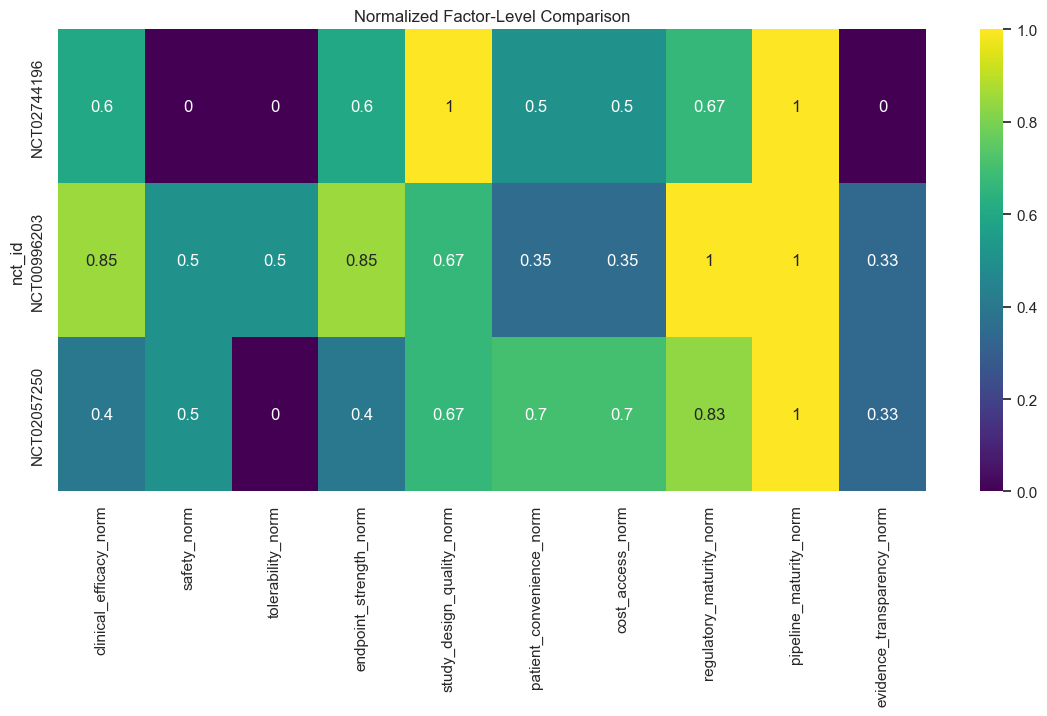

In [30]:
heatmap_cols = [
    'clinical_efficacy_norm',
    'safety_norm',
    'tolerability_norm',
    'endpoint_strength_norm',
    'study_design_quality_norm',
    'patient_convenience_norm',
    'cost_access_norm',
    'regulatory_maturity_norm',
    'pipeline_maturity_norm',
    'evidence_transparency_norm'
]

available_heatmap_cols = [c for c in heatmap_cols if c in scored_df.columns]

plt.figure(figsize=(14, 6))
sns.heatmap(
    scored_df.set_index('nct_id')[available_heatmap_cols],
    annot=True,
    cmap='viridis',
    vmin=0,
    vmax=1
)
plt.title('Normalized Factor-Level Comparison')
plt.show()


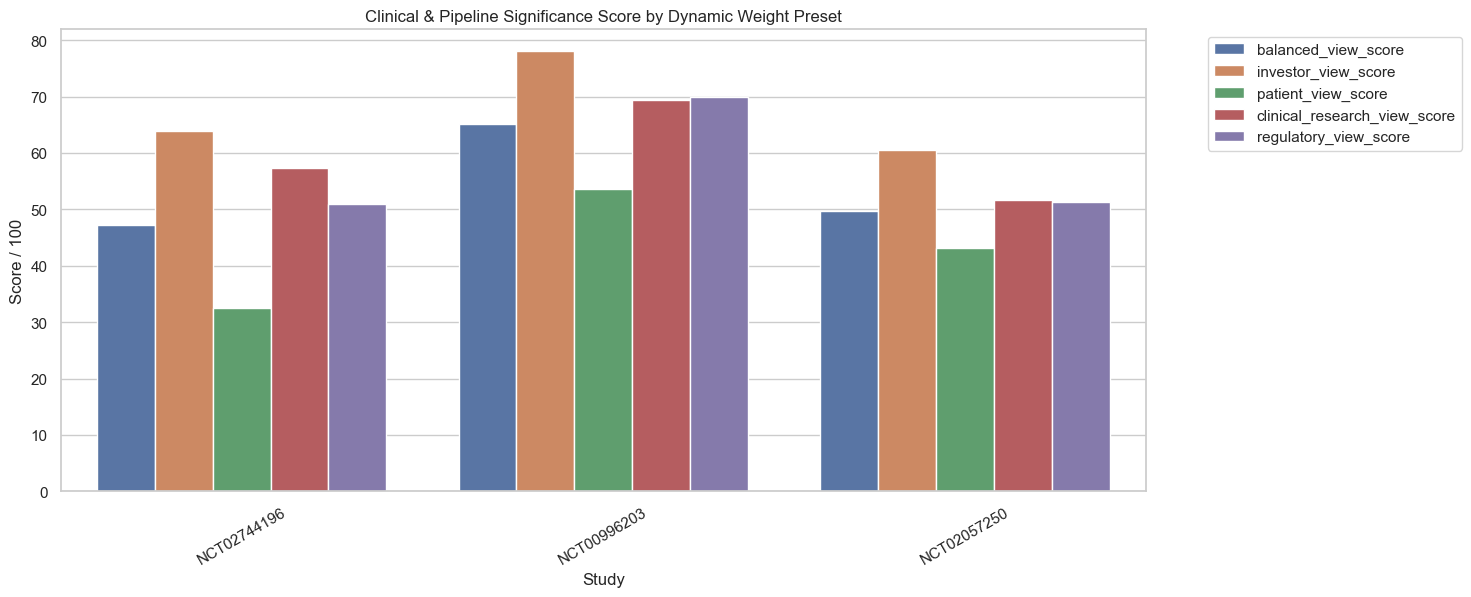

In [31]:
score_cols = [
    'balanced_view_score',
    'investor_view_score',
    'patient_view_score',
    'clinical_research_view_score',
    'regulatory_view_score'
]

plot_df = scored_df[['nct_id'] + score_cols].melt(
    id_vars='nct_id',
    var_name='view',
    value_name='score'
)

plt.figure(figsize=(14, 6))
sns.barplot(data=plot_df, x='nct_id', y='score', hue='view')
plt.title('Clinical & Pipeline Significance Score by Dynamic Weight Preset')
plt.ylabel('Score / 100')
plt.xlabel('Study')
plt.xticks(rotation=30)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


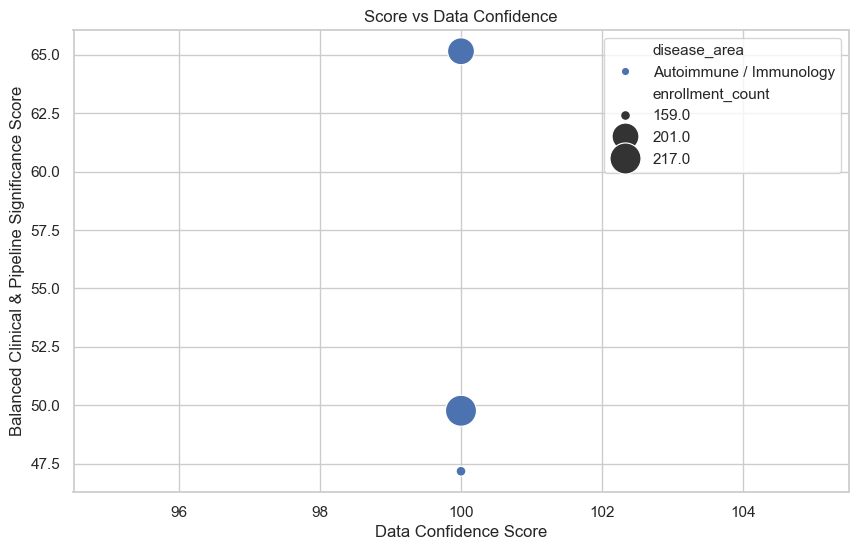

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=scored_df,
    x='data_confidence_score',
    y='balanced_view_score',
    hue='disease_area',
    size='enrollment_count',
    sizes=(50, 500)
)
plt.title('Score vs Data Confidence')
plt.xlabel('Data Confidence Score')
plt.ylabel('Balanced Clinical & Pipeline Significance Score')
plt.show()


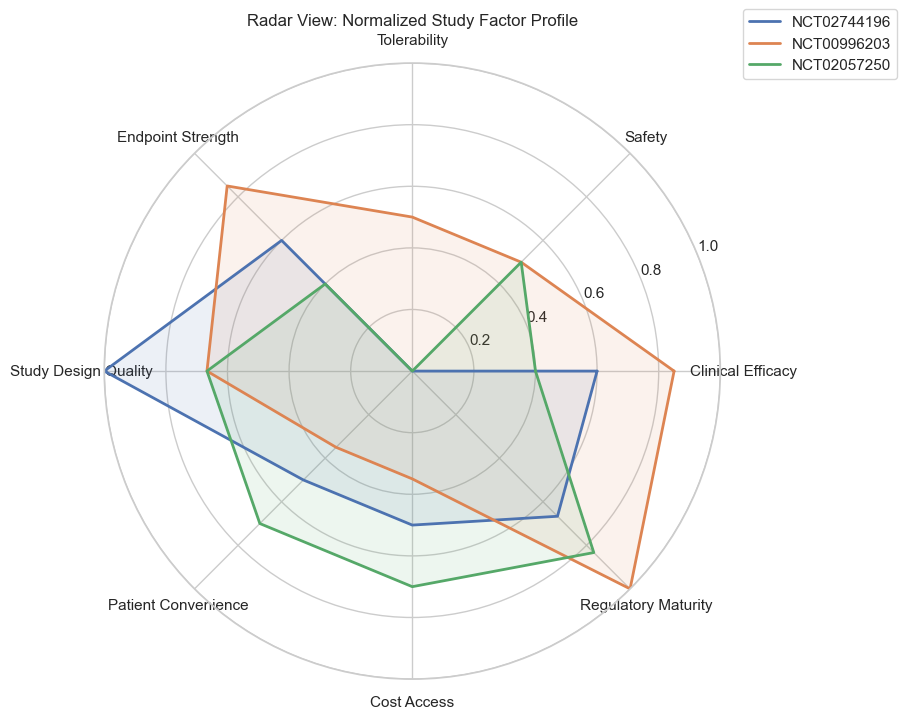

In [33]:
def plot_radar_for_studies(scored_df, nct_ids, factor_cols):
    labels = [c.replace('_norm', '').replace('_', ' ').title() for c in factor_cols]
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)

    for nct_id in nct_ids:
        row = scored_df[scored_df['nct_id'] == nct_id]
        if row.empty:
            continue

        values = row[factor_cols].iloc[0].fillna(0).tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=nct_id)
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1)
    plt.title('Radar View: Normalized Study Factor Profile')
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

radar_cols = available_heatmap_cols[:8]
plot_radar_for_studies(scored_df, scored_df['nct_id'].tolist(), radar_cols)


In [34]:
def generate_strengths_risks(row):
    strengths = []
    risks = []
    missing = []

    if row.get('phase_numeric', 0) >= 3:
        strengths.append('Late-stage clinical development signal')
    elif row.get('phase_numeric', 0) <= 1:
        risks.append('Early-stage evidence only')

    if row.get('enrollment_count', 0) >= 200:
        strengths.append('Moderate-to-large enrollment')
    elif row.get('enrollment_count', 0) < 50:
        risks.append('Small enrollment size')

    if row.get('has_results', 0) == 1:
        strengths.append('Results are available in the source record')
    else:
        missing.append('No posted results found in ClinicalTrials.gov record')

    if row.get('publication_count', 0) > 0:
        strengths.append('Linked publication evidence available')
    else:
        missing.append('No linked publication found')

    if row.get('primary_endpoint_count', 0) > 0:
        strengths.append('Primary endpoint available')
    else:
        risks.append('Primary endpoint not clearly available')

    if row.get('is_randomized', 0) == 1:
        strengths.append('Randomized design signal')
    else:
        risks.append('Randomization not clearly identified')

    if row.get('has_masking', 0) == 1:
        strengths.append('Masking/blinding signal available')
    else:
        risks.append('Masking/blinding not clearly identified')

    if row.get('country_count', 0) > 1:
        strengths.append('Multi-country study signal')
    else:
        risks.append('Limited geographic diversity based on available locations')

    if row.get('is_negative_status', 0) == 1:
        risks.append('Terminated, withdrawn, or suspended status signal')

    return {
        'strengths': strengths,
        'risks': risks,
        'missing_data': missing
    }

flags = scored_df.apply(generate_strengths_risks, axis=1)
scored_df['strengths'] = flags.apply(lambda x: x['strengths'])
scored_df['risks'] = flags.apply(lambda x: x['risks'])
scored_df['missing_data'] = flags.apply(lambda x: x['missing_data'])

display(scored_df[['nct_id', 'strengths', 'risks', 'missing_data']])


,nct_id,strengths,risks,missing_data
0,NCT02744196,"[Late-stage clinical development signal, Primary endpoint available, Randomized design signal, Masking/blinding signal available]",[Limited geographic diversity based on available locations],"[No posted results found in ClinicalTrials.gov record, No linked publication found]"
1,NCT00996203,"[Late-stage clinical development signal, Moderate-to-large enrollment, Results are available in the source record, Primary endpoint available, Randomized de...","[Masking/blinding not clearly identified, Limited geographic diversity based on available locations]",[No linked publication found]
2,NCT02057250,"[Late-stage clinical development signal, Moderate-to-large enrollment, Results are available in the source record, Primary endpoint available, Randomized de...",[Masking/blinding not clearly identified],[No linked publication found]


In [24]:
def build_pipeline_summary(df):
    temp = df.copy()

    temp['enrollment'] = pd.to_numeric(temp['enrollment'], errors='coerce')
    temp['phase_numeric'] = temp['phase'].apply(phase_to_numeric)
    temp['status_norm'] = temp['status'].fillna('').str.lower()

    group_cols = ['category', 'sponsor', 'phase', 'status']

    pipeline = temp.groupby(group_cols).agg(
        number_of_studies=('nct_id', 'count'),
        average_enrollment=('enrollment', 'mean'),
        max_enrollment=('enrollment', 'max'),
        average_phase_numeric=('phase_numeric', 'mean'),
    ).reset_index()

    pipeline['completed_flag'] = pipeline['status'].str.lower().str.contains('completed', na=False)
    pipeline['active_flag'] = pipeline['status'].str.lower().str.contains('recruiting|active|not yet', na=False)
    pipeline['negative_status_flag'] = pipeline['status'].str.lower().str.contains('terminated|withdrawn|suspended', na=False)

    return pipeline.sort_values('number_of_studies', ascending=False)

pipeline_summary_df = build_pipeline_summary(df)
display(pipeline_summary_df.head(30))


,category,sponsor,phase,status,number_of_studies,average_enrollment,max_enrollment,average_phase_numeric,completed_flag,active_flag,negative_status_flag
1991,Oncology,National Cancer Institute (NCI),PHASE2,COMPLETED,31,43.516129,101,2.0,True,False,False
632,Autoimmune,Novo Nordisk A/S,PHASE3,COMPLETED,26,916.692308,9341,3.0,True,False,False
629,Autoimmune,Novo Nordisk A/S,PHASE1,COMPLETED,21,64.619048,384,1.0,True,False,False
1986,Oncology,National Cancer Institute (NCI),PHASE1,COMPLETED,20,32.750000,58,1.0,True,False,False
1858,Oncology,M.D. Anderson Cancer Center,PHASE2,COMPLETED,16,63.062500,197,2.0,True,False,False
263,Autoimmune,Eli Lilly and Company,PHASE3,COMPLETED,14,1131.714286,9901,3.0,True,False,False
1852,Oncology,M.D. Anderson Cancer Center,PHASE1,COMPLETED,12,25.416667,63,1.0,True,False,False
1677,Oncology,Hoffmann-La Roche,PHASE3,COMPLETED,11,782.272727,2185,3.0,True,False,False
92,Autoimmune,AstraZeneca,PHASE3,COMPLETED,9,2335.444444,17190,3.0,True,False,False
758,Autoimmune,Sanofi,PHASE4,COMPLETED,9,1064.888889,7376,4.0,True,False,False


/var/folders/6c/_s9vdlvj0z3dmgnwfhss_9lm0000gq/T/ipykernel_64476/4119430006.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_temp, x='phase', y='enrollment', ax=axes[2,0], palette='coolwarm')


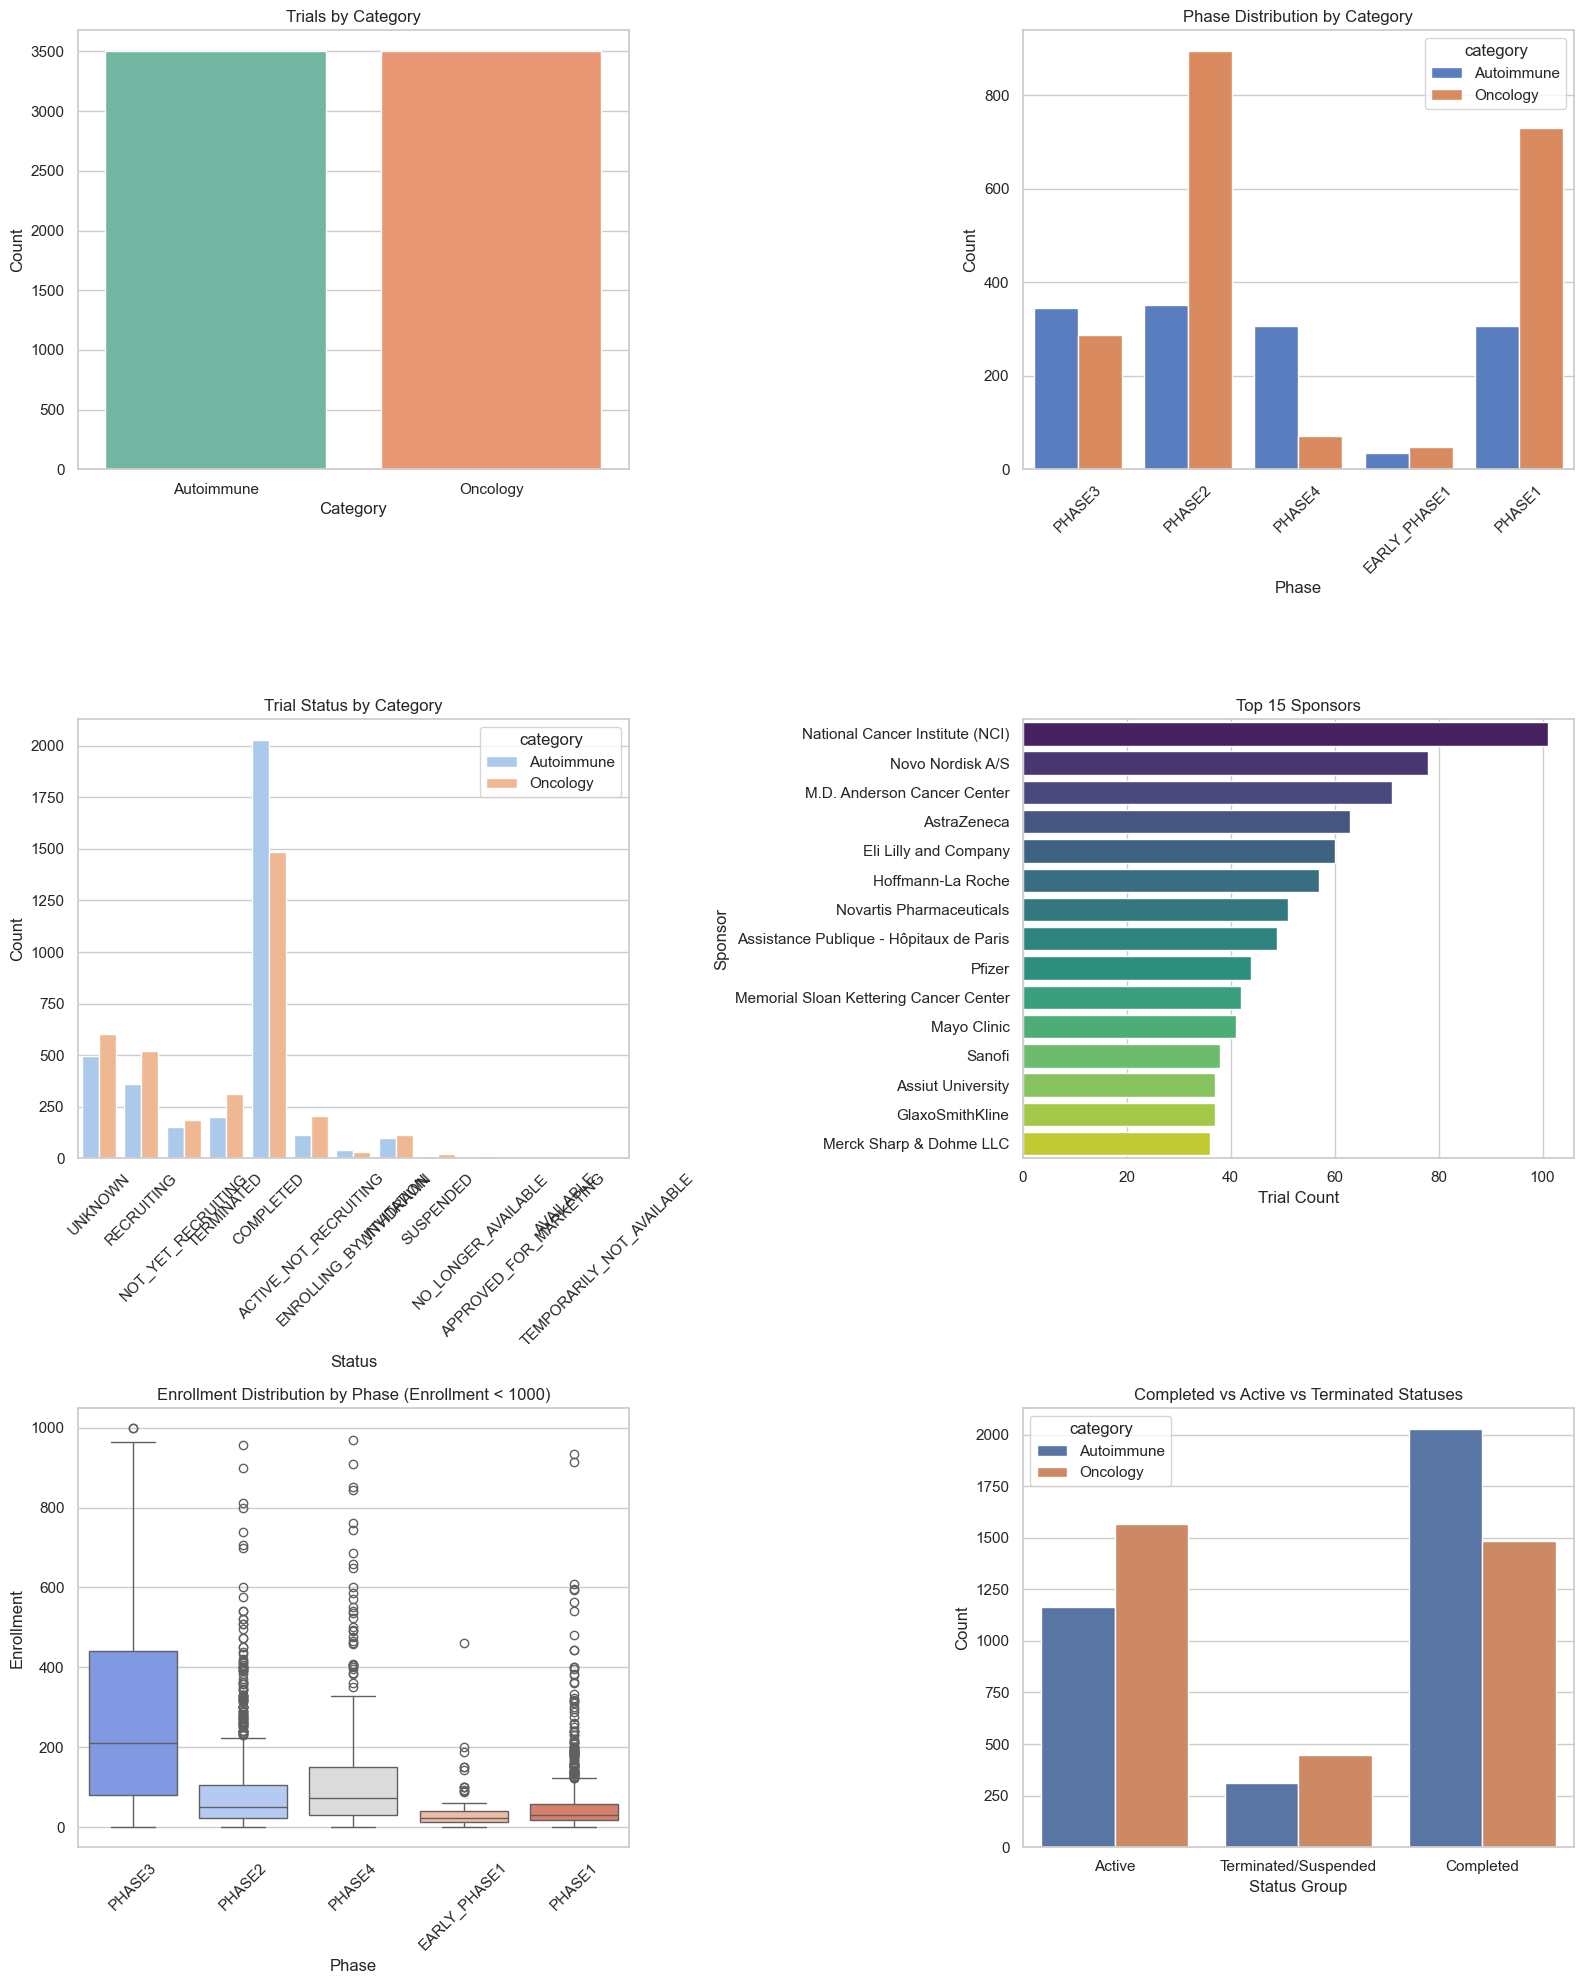

In [25]:
fig, axes = plt.subplots(3, 2, figsize=(16, 20))

# 1. Trials by category
sns.countplot(data=df, x='category', ax=axes[0,0], hue='category', legend=False, palette='Set2')
axes[0,0].set_title('Trials by Category')
axes[0,0].set_xlabel('Category')
axes[0,0].set_ylabel('Count')

# 2. Phase by category
sns.countplot(data=df, x='phase', hue='category', ax=axes[0,1], palette='muted')
axes[0,1].set_title('Phase Distribution by Category')
axes[0,1].set_xlabel('Phase')
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Status by category
sns.countplot(data=df, x='status', hue='category', ax=axes[1,0], palette='pastel')
axes[1,0].set_title('Trial Status by Category')
axes[1,0].set_xlabel('Status')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Top 15 sponsors
top_sponsors = df['sponsor'].value_counts().head(15).reset_index()
sns.barplot(data=top_sponsors, y='sponsor', x='count', ax=axes[1,1], hue='sponsor', legend=False, palette='viridis')
axes[1,1].set_title('Top 15 Sponsors')
axes[1,1].set_xlabel('Trial Count')
axes[1,1].set_ylabel('Sponsor')

# 5. Enrollment by phase
df_temp = df.copy()
df_temp['enrollment'] = pd.to_numeric(df_temp['enrollment'], errors='coerce')
df_temp = df_temp[df_temp['enrollment'] < 1000]  # Filter extreme outliers for plotting
sns.boxplot(data=df_temp, x='phase', y='enrollment', ax=axes[2,0], palette='coolwarm')
axes[2,0].set_title('Enrollment Distribution by Phase (Enrollment < 1000)')
axes[2,0].set_xlabel('Phase')
axes[2,0].set_ylabel('Enrollment')
axes[2,0].tick_params(axis='x', rotation=45)

# 6. Completed vs active vs terminated
df_status = df.copy()
df_status['status_class'] = 'Active'
df_status.loc[df_status['status'].fillna('').str.lower().str.contains('completed'), 'status_class'] = 'Completed'
df_status.loc[df_status['status'].fillna('').str.lower().str.contains('terminated|withdrawn|suspended'), 'status_class'] = 'Terminated/Suspended'
sns.countplot(data=df_status, x='status_class', hue='category', ax=axes[2,1], palette='deep')
axes[2,1].set_title('Completed vs Active vs Terminated Statuses')
axes[2,1].set_xlabel('Status Group')
axes[2,1].set_ylabel('Count')

plt.tight_layout()
plt.show()


## Competitive Benchmark: Why This Matters

Large clinical intelligence platforms focus on trial design, enrollment timelines, patient populations, endpoints, outcomes, geography, sites, investigators, and drug development pipelines.

MindReader’s opportunity is to create a more explainable decision layer:
- Start from public clinical trial data
- Extract comparable structured factors
- Normalize factors into a common scale
- Apply dynamic weights depending on user view
- Produce a transparent Clinical & Pipeline Significance Score
- Explain why a study or pipeline looks strong, weak, risky, or incomplete

This does not replace enterprise clinical databases. It demonstrates an approval-ready method for turning complex trial data into understandable biotech intelligence.

### Industry Context:
- **Reference platform**: Citeline
- **Reference website**: [Citeline](https://www.citeline.com/en/)
- **MindReader site**: [MindReader Biotech](https://www.mindreaderbio.tech/)

Do not copy Citeline’s product. Use it only as market context.


In [26]:
def generate_plain_english_interpretation(scored_df, selected_score_col='balanced_view_score'):
    if scored_df.empty:
        return 'No studies available for interpretation.'

    best = scored_df.sort_values(selected_score_col, ascending=False).iloc[0]
    weakest = scored_df.sort_values(selected_score_col, ascending=True).iloc[0]
    lowest_conf = scored_df.sort_values('data_confidence_score', ascending=True).iloc[0]

    lines = []

    lines.append('## So What It Means')
    lines.append('')
    lines.append(
        f"Based on the selected scoring view, **{best['nct_id']}** has the strongest Clinical & Pipeline Significance Score "
        f"({best[selected_score_col]}/100). This appears to be driven by factors such as endpoint strength, study maturity, design quality, "
        f"results/publication transparency, patient convenience, and pipeline context where available."
    )
    lines.append('')
    lines.append(
        f"**{weakest['nct_id']}** has the lowest score in this selected comparison ({weakest[selected_score_col]}/100). "
        f"This does not mean the therapy failed. It means the available structured data gives weaker evidence or more missing/risk signals under the current weighting method."
    )
    lines.append('')
    lines.append(
        f"The study with the lowest data confidence is **{lowest_conf['nct_id']}** ({lowest_conf['data_confidence_score']}/100). "
        f"This means its score should be interpreted carefully because some source fields are missing or incomplete."
    )
    lines.append('')
    lines.append('### Key Reminder')
    lines.append('')
    lines.append(
        'A low score in the comparison does not represent a lack of therapeutic potential or clinical failure. '
        'It indicates that under the active weighting preset (e.g., balanced, patient, or investor view), the study '
        'has fewer of the positive structural indicators (such as late-stage phase, high enrollment, posted results, or '
        'highly convenient modality like oral administration) or carries specific penalties (like negative overall status or missing endpoints).'
    )
    lines.append('')
    lines.append('### Transparent Score Breakdown')
    for idx, row in scored_df.iterrows():
        lines.append(f"- **{row['nct_id']} ({row['sponsor']})**:")
        lines.append(f"  - Clinical & Pipeline Significance Score ({selected_score_col}): **{row[selected_score_col]}/100**")
        lines.append(f"  - Data Confidence Score: **{row['data_confidence_score']}/100**")
        
        # Breakdown of contributing factors
        breakdown = row.get(f"{selected_score_col.replace('_score', '')}_breakdown", {})
        lines.append('  - Major Contributing Dimension Contributions:')
        for dim, details in breakdown.items():
            if details.get('weighted_contribution', 0) > 0.01:
                lines.append(f"    - {dim.replace('_', ' ').title()}: {round(details['weighted_contribution'] * 100, 1)} points (Normalized Value: {details['normalized_value']}, Weight: {details['weight']})")
        
        penalties = row.get(f"{selected_score_col.replace('_score', '')}_penalty", 0)
        reasons = row.get(f"{selected_score_col.replace('_score', '')}_penalty_reasons", [])
        if penalties > 0:
            lines.append(f"  - Applied Penalties: -{round(penalties, 1)} points due to: {', '.join(reasons)}")
            
    return '\n'.join(lines)

interpretation_md = generate_plain_english_interpretation(scored_df, 'balanced_view_score')
from IPython.display import Markdown
display(Markdown(interpretation_md))


## So What It Means

Based on the selected scoring view, **NCT00996203** has the strongest Clinical & Pipeline Significance Score (65.15/100). This appears to be driven by factors such as endpoint strength, study maturity, design quality, results/publication transparency, patient convenience, and pipeline context where available.

**NCT02744196** has the lowest score in this selected comparison (47.17/100). This does not mean the therapy failed. It means the available structured data gives weaker evidence or more missing/risk signals under the current weighting method.

The study with the lowest data confidence is **NCT02744196** (100.0/100). This means its score should be interpreted carefully because some source fields are missing or incomplete.

### Key Reminder

A low score in the comparison does not represent a lack of therapeutic potential or clinical failure. It indicates that under the active weighting preset (e.g., balanced, patient, or investor view), the study has fewer of the positive structural indicators (such as late-stage phase, high enrollment, posted results, or highly convenient modality like oral administration) or carries specific penalties (like negative overall status or missing endpoints).

### Transparent Score Breakdown
- **NCT02744196 (Biocad)**:
  - Clinical & Pipeline Significance Score (balanced_view_score): **47.17/100**
  - Data Confidence Score: **100.0/100**
  - Major Contributing Dimension Contributions:
    - Clinical Efficacy: 12.0 points (Normalized Value: 0.6, Weight: 0.2)
    - Endpoint Strength: 6.0 points (Normalized Value: 0.6, Weight: 0.1)
    - Study Design Quality: 10.0 points (Normalized Value: 1.0, Weight: 0.1)
    - Patient Convenience: 5.0 points (Normalized Value: 0.5, Weight: 0.1)
    - Regulatory Maturity: 6.7 points (Normalized Value: 0.6667, Weight: 0.1)
    - Pipeline Maturity: 5.0 points (Normalized Value: 1.0, Weight: 0.05)
    - Cost Access: 2.5 points (Normalized Value: 0.5, Weight: 0.05)
- **NCT00996203 (Hoffmann-La Roche)**:
  - Clinical & Pipeline Significance Score (balanced_view_score): **65.15/100**
  - Data Confidence Score: **100.0/100**
  - Major Contributing Dimension Contributions:
    - Clinical Efficacy: 17.0 points (Normalized Value: 0.85, Weight: 0.2)
    - Safety: 7.5 points (Normalized Value: 0.5, Weight: 0.15)
    - Tolerability: 5.0 points (Normalized Value: 0.5, Weight: 0.1)
    - Endpoint Strength: 8.5 points (Normalized Value: 0.85, Weight: 0.1)
    - Study Design Quality: 6.7 points (Normalized Value: 0.6667, Weight: 0.1)
    - Patient Convenience: 3.5 points (Normalized Value: 0.35, Weight: 0.1)
    - Regulatory Maturity: 10.0 points (Normalized Value: 1.0, Weight: 0.1)
    - Pipeline Maturity: 5.0 points (Normalized Value: 1.0, Weight: 0.05)
    - Evidence Transparency: 1.7 points (Normalized Value: 0.3333, Weight: 0.05)
    - Cost Access: 1.8 points (Normalized Value: 0.35, Weight: 0.05)
  - Applied Penalties: -1.4 points due to: Pipeline termination-risk penalty
- **NCT02057250 (Sanofi)**:
  - Clinical & Pipeline Significance Score (balanced_view_score): **49.76/100**
  - Data Confidence Score: **100.0/100**
  - Major Contributing Dimension Contributions:
    - Clinical Efficacy: 8.0 points (Normalized Value: 0.4, Weight: 0.2)
    - Safety: 7.5 points (Normalized Value: 0.5, Weight: 0.15)
    - Endpoint Strength: 4.0 points (Normalized Value: 0.4, Weight: 0.1)
    - Study Design Quality: 6.7 points (Normalized Value: 0.6667, Weight: 0.1)
    - Patient Convenience: 7.0 points (Normalized Value: 0.7, Weight: 0.1)
    - Regulatory Maturity: 8.3 points (Normalized Value: 0.8333, Weight: 0.1)
    - Pipeline Maturity: 5.0 points (Normalized Value: 1.0, Weight: 0.05)
    - Evidence Transparency: 1.7 points (Normalized Value: 0.3333, Weight: 0.05)
    - Cost Access: 3.5 points (Normalized Value: 0.7, Weight: 0.05)
  - Applied Penalties: -1.9 points due to: Pipeline termination-risk penalty

# Dynamic AI Trial Analysis Layer

This section upgrades the notebook from a rule-based scoring prototype into a
dynamic, AI-assisted, evidence-grounded trial analysis system.

Instead of generic summaries, MindReader analyses each trial **one dimension at
a time**, forcing the AI to stay grounded in the source data and to
explicitly flag missing evidence.

```
Structured source data
    ↓
Dynamic dimension registry
    ↓
Feature availability check
    ↓
AI analysis one dimension at a time
    ↓
JSON output validation
    ↓
Evidence-gap detection
    ↓
Final trial intelligence card
```


In [36]:
# ── LLM initialisation ───────────────────────────────────────────────────────
import os
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())

api_key = os.getenv('OPENROUTER_API_KEY')
if not api_key:
    raise ValueError('OPENROUTER_API_KEY not found. Add it to your .env file.')

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model='openrouter/free',
    openai_api_key=api_key,
    openai_api_base='https://openrouter.ai/api/v1',
    temperature=0.2,
    max_tokens=3000,
    default_headers={
        'HTTP-Referer': 'https://mindreaderbio.tech',
        'X-Title': 'MindReader Biotech Intelligence',
    },
)
print('LLM ready:', llm.model_name)


LLM ready: openrouter/free


In [37]:
# ── 1. Dynamic Analysis Dimension Registry ───────────────────────────────────
ANALYSIS_DIMENSION_REGISTRY = {
    'trial_identity': {
        'display_name': 'Trial Identity',
        'purpose': 'Identify what is being tested, in whom, by whom, and at what stage.',
        'required_fields': ['nct_id', 'brief_title', 'conditions', 'intervention_names', 'lead_sponsor', 'phase', 'status'],
        'optional_fields': ['official_title', 'study_type', 'primary_purpose', 'enrollment_count'],
        'analysis_questions': [
            'What is the trial testing?',
            'What disease or condition is being studied?',
            'What intervention or therapy is being evaluated?',
            'Who is the sponsor?',
            'What stage of development does the trial appear to represent?',
        ],
        'forbidden_claims': [
            'Do not infer efficacy.',
            'Do not infer safety.',
            'Do not claim regulatory approval.',
        ],
    },
    'clinical_efficacy_interpretability': {
        'display_name': 'Clinical Efficacy Interpretability',
        'purpose': 'Assess whether available source data allows interpretation of therapeutic benefit.',
        'required_fields': ['primary_outcomes', 'secondary_outcomes', 'has_results'],
        'optional_fields': ['raw_results_available', 'endpoint_type', 'status', 'enrollment_count'],
        'analysis_questions': [
            'Are efficacy endpoints available?',
            'Are results posted?',
            'Can therapeutic benefit be interpreted from the available source data?',
            'Are endpoints clinically meaningful or only surrogate/intermediate?',
            'What evidence is missing before efficacy can be judged?',
        ],
        'forbidden_claims': [
            'Do not say the therapy works unless source results support it.',
            'Do not invent p-values, effect sizes, or response rates.',
            'Do not infer clinical success from phase alone.',
        ],
    },
    'endpoint_meaningfulness': {
        'display_name': 'Endpoint Meaningfulness',
        'purpose': 'Judge whether endpoints are hard clinical, patient-centered, surrogate, biomarker, safety-only, or unclear.',
        'required_fields': ['primary_outcomes', 'secondary_outcomes'],
        'optional_fields': ['endpoint_type', 'primary_purpose', 'conditions'],
        'analysis_questions': [
            'What are the primary endpoints?',
            'Are endpoints hard clinical outcomes, patient-reported outcomes, surrogate endpoints, biomarkers, safety endpoints, or unclear?',
            'Do the endpoints align with the disease context?',
            'Would a non-expert understand why these endpoints matter?',
        ],
        'forbidden_claims': [
            'Do not claim endpoint success unless results are available.',
            'Do not assume regulatory acceptance of an endpoint.',
        ],
    },
    'safety_and_tolerability': {
        'display_name': 'Safety and Tolerability',
        'purpose': 'Assess what safety and tolerability information is available or missing.',
        'required_fields': ['has_results', 'primary_outcomes', 'secondary_outcomes'],
        'optional_fields': ['raw_results_available'],
        'analysis_questions': [
            'Is safety directly measured?',
            'Are adverse events available in source data?',
            'Are serious adverse events available?',
            'Is tolerability measured through discontinuation, withdrawal, QoL, or patient-reported outcomes?',
            'What safety/tolerability evidence is missing?',
        ],
        'forbidden_claims': [
            'Do not say the therapy has no side effects unless adverse-event data proves it.',
            'Do not invent adverse events.',
            'Do not infer tolerability only from study completion.',
        ],
    },
    'patient_adoption_burden': {
        'display_name': 'Patient Adoption Burden',
        'purpose': 'Analyze how easy or difficult the therapy may be for patients to use.',
        'required_fields': ['intervention_names', 'intervention_types'],
        'optional_fields': ['eligibility_criteria', 'countries', 'facility_count', 'primary_outcomes', 'secondary_outcomes'],
        'analysis_questions': [
            'Does the therapy appear oral, injectable, infusion-based, device-based, procedural, behavioral, or unclear?',
            'Does source data suggest patient burden such as visits, monitoring, specialized sites, or complex administration?',
            'Is home use likely or not inferable?',
            'What convenience information is missing?',
        ],
        'forbidden_claims': [
            'Do not invent dosing frequency.',
            'Do not invent cost.',
            'Do not infer home use unless source data suggests it.',
        ],
    },
    'population_relevance': {
        'display_name': 'Population Relevance',
        'purpose': 'Assess whether the enrolled population is clear, broad, narrow, biomarker-selected, severe, refractory, pediatric, adult, or unclear.',
        'required_fields': ['conditions', 'minimum_age', 'maximum_age', 'sex', 'eligibility_criteria'],
        'optional_fields': ['enrollment_count', 'countries', 'facility_count'],
        'analysis_questions': [
            'Who is eligible for the trial?',
            'Is the patient population broad or narrow?',
            'Are there age, sex, severity, prior-treatment, or biomarker restrictions?',
            'How generalizable does the population appear based on available data?',
        ],
        'forbidden_claims': [
            'Do not infer real-world generalizability beyond source data.',
            'Do not invent demographic diversity.',
        ],
    },
    'study_design_quality': {
        'display_name': 'Study Design Quality',
        'purpose': 'Assess design robustness based on randomization, comparator, masking, arms, study type, enrollment, and duration.',
        'required_fields': ['study_type', 'allocation', 'intervention_model', 'masking', 'number_of_arms', 'enrollment_count'],
        'optional_fields': ['primary_purpose', 'start_date', 'completion_date', 'countries', 'facility_count'],
        'analysis_questions': [
            'Is the study interventional or observational?',
            'Is randomization available?',
            'Is masking/blinding available?',
            'Is there a comparator or control signal?',
            'Is enrollment size adequate for interpretation?',
            'What design limitations are visible?',
        ],
        'forbidden_claims': [
            'Do not call a study definitive unless source evidence supports it.',
            'Do not infer statistical power unless sample-size assumptions are available.',
        ],
    },
    'regulatory_readiness': {
        'display_name': 'Regulatory Readiness',
        'purpose': 'Assess whether the trial looks exploratory, supportive, pivotal-like, or insufficient based on available structured data.',
        'required_fields': ['phase', 'status', 'has_results', 'primary_outcomes', 'study_type', 'enrollment_count'],
        'optional_fields': ['completion_date', 'publication_count', 'sponsor_class'],
        'analysis_questions': [
            'Does the trial appear early exploratory, mid-stage, late-stage, post-marketing, or unclear?',
            'Are results available?',
            'Are endpoints and design strong enough to support regulatory interpretation?',
            'What regulatory evidence is missing?',
        ],
        'forbidden_claims': [
            'Do not claim FDA/EMA approval likelihood.',
            'Do not claim the study is pivotal unless explicitly supported.',
            'Do not infer regulatory success.',
        ],
    },
    'economic_and_access_relevance': {
        'display_name': 'Economic and Access Relevance',
        'purpose': 'Identify cost/access questions and available proxies, without inventing price.',
        'required_fields': ['intervention_names', 'intervention_types', 'facility_count', 'countries'],
        'optional_fields': ['eligibility_criteria'],
        'analysis_questions': [
            'What cost/access factors can be inferred as questions or proxies?',
            'Does the intervention suggest expensive delivery such as infusion, biologic, cell therapy, specialized procedure, or device?',
            'Does the trial setting suggest specialized access burden?',
            'What pricing/reimbursement evidence is missing?',
        ],
        'forbidden_claims': [
            'Do not invent drug price.',
            'Do not invent reimbursement status.',
            'Do not claim cost-effectiveness unless economic data is available.',
        ],
    },
    'evidence_transparency': {
        'display_name': 'Evidence Transparency',
        'purpose': 'Assess whether the study has enough visible evidence to support interpretation.',
        'required_fields': ['has_results', 'publication_count', 'primary_outcomes', 'secondary_outcomes', 'status'],
        'optional_fields': ['completion_date', 'raw_results_available', 'publications'],
        'analysis_questions': [
            'Are results posted?',
            'Are publications linked?',
            'Are endpoints available?',
            'Is the study completed but missing results?',
            'What evidence should be reviewed next?',
        ],
        'forbidden_claims': [
            'Do not treat missing data as negative efficacy.',
            'Do not overinterpret incomplete records.',
        ],
    },
    'red_team_risk_review': {
        'display_name': 'Red-Team Risk Review',
        'purpose': 'Identify what could be misleading if someone only looked at phase, title, sponsor, or score.',
        'required_fields': ['nct_id', 'brief_title', 'phase', 'status', 'has_results', 'primary_outcomes', 'enrollment_count'],
        'optional_fields': ['publication_count', 'countries', 'facility_count'],
        'analysis_questions': [
            'What could be misleading about this trial?',
            'What should a user not conclude from the available data?',
            'What is the biggest interpretation risk?',
            'What evidence would change the analysis?',
        ],
        'forbidden_claims': [
            'Do not provide investment advice.',
            'Do not make treatment recommendations.',
            'Do not predict clinical success.',
        ],
    },
}

print(f'Registered {len(ANALYSIS_DIMENSION_REGISTRY)} analysis dimensions.')


Registered 11 analysis dimensions.


In [38]:
# ── 2. Dimension Availability Checker ────────────────────────────────────────
import pandas as pd

def get_available_analysis_dimensions(trial_data, registry):
    available = []
    for key, config in registry.items():
        required_fields = config.get('required_fields', [])
        present_count = 0
        for field in required_fields:
            value = trial_data.get(field)
            if value is None:
                continue
            if isinstance(value, float) and pd.isna(value):
                continue
            if isinstance(value, str) and value.strip() == '':
                continue
            if isinstance(value, list) and len(value) == 0:
                continue
            present_count += 1
        coverage = present_count / max(len(required_fields), 1)
        if coverage >= 0.4:
            status = 'available'
        elif coverage > 0:
            status = 'partial'
        else:
            status = 'insufficient'
        available.append({
            'dimension': key,
            'display_name': config['display_name'],
            'coverage': round(coverage, 2),
            'status': status,
            'required_fields': required_fields,
            'present_required_fields': present_count,
            'total_required_fields': len(required_fields),
        })
    return pd.DataFrame(available).sort_values('coverage', ascending=False)

if parsed_studies:
    sample_avail = get_available_analysis_dimensions(parsed_studies[0], ANALYSIS_DIMENSION_REGISTRY)
    display(sample_avail[['display_name', 'coverage', 'status', 'present_required_fields', 'total_required_fields']])


,display_name,coverage,status,present_required_fields,total_required_fields
0,Trial Identity,1.00,available,7,7
1,Clinical Efficacy Interpretability,1.00,available,3,3
2,Endpoint Meaningfulness,1.00,available,2,2
3,Safety and Tolerability,1.00,available,3,3
4,Patient Adoption Burden,1.00,available,2,2
5,Population Relevance,1.00,available,5,5
6,Study Design Quality,1.00,available,6,6
7,Regulatory Readiness,1.00,available,6,6
9,Evidence Transparency,1.00,available,5,5
10,Red-Team Risk Review,1.00,available,7,7


In [39]:
# ── 3. Trial AI Context Builder ──────────────────────────────────────────────
def prepare_trial_ai_context(trial_data, scored_row=None, max_text_chars=1500):
    context = {
        'source_note': 'Use only this structured source data. If something is missing, say Not available in source data.',
        'trial_identity': {
            'nct_id': trial_data.get('nct_id'),
            'brief_title': trial_data.get('brief_title'),
            'official_title': trial_data.get('official_title'),
            'status': trial_data.get('status'),
            'phase': trial_data.get('phase'),
            'study_type': trial_data.get('study_type'),
            'lead_sponsor': trial_data.get('lead_sponsor'),
            'sponsor_class': trial_data.get('sponsor_class'),
        },
        'disease_and_intervention': {
            'conditions': trial_data.get('conditions'),
            'keywords': trial_data.get('keywords'),
            'intervention_names': trial_data.get('intervention_names'),
            'intervention_types': trial_data.get('intervention_types'),
        },
        'design': {
            'allocation': trial_data.get('allocation'),
            'intervention_model': trial_data.get('intervention_model'),
            'masking': trial_data.get('masking'),
            'primary_purpose': trial_data.get('primary_purpose'),
            'number_of_arms': trial_data.get('number_of_arms'),
            'enrollment_count': trial_data.get('enrollment_count'),
            'start_date': trial_data.get('start_date'),
            'primary_completion_date': trial_data.get('primary_completion_date'),
            'completion_date': trial_data.get('completion_date'),
        },
        'outcomes': {
            'primary_outcomes': trial_data.get('primary_outcomes'),
            'secondary_outcomes': trial_data.get('secondary_outcomes'),
            'other_outcomes': trial_data.get('other_outcomes'),
        },
        'eligibility': {
            'minimum_age': trial_data.get('minimum_age'),
            'maximum_age': trial_data.get('maximum_age'),
            'sex': trial_data.get('sex'),
            'healthy_volunteers': trial_data.get('healthy_volunteers'),
            'eligibility_criteria_excerpt': str(trial_data.get('eligibility_criteria', ''))[:max_text_chars],
        },
        'locations': {
            'countries': trial_data.get('countries'),
            'facility_count': trial_data.get('facility_count'),
        },
        'evidence': {
            'has_results': trial_data.get('has_results'),
            'raw_results_available': trial_data.get('raw_results_available'),
            'publication_count': trial_data.get('publication_count'),
            'publications': trial_data.get('publications'),
        },
    }
    if scored_row is not None:
        sr = scored_row
        context['scores'] = {
            'balanced_view_score': float(sr.get('balanced_view_score', 0)),
            'investor_view_score': float(sr.get('investor_view_score', 0)),
            'patient_view_score': float(sr.get('patient_view_score', 0)),
            'clinical_research_view_score': float(sr.get('clinical_research_view_score', 0)),
            'regulatory_view_score': float(sr.get('regulatory_view_score', 0)),
            'data_confidence_score': float(sr.get('data_confidence_score', 0)),
            'endpoint_type': sr.get('endpoint_type'),
            'disease_area': sr.get('disease_area'),
            'modality': sr.get('modality'),
        }
    return context


In [40]:
# ── 4. Strict AI Prompt Builder ──────────────────────────────────────────────
import json

OUTPUT_SCHEMA_TEMPLATE = '''
{{
  "dimension_key": "{dim_key}",
  "dimension_name": "{dim_name}",
  "nct_id": "{nct}",
  "summary": "2-5 sentence analysis grounded only in source data.",
  "positive_signals": ["specific positive signal from source data"],
  "risk_signals": ["specific risk, limitation, or uncertainty from source data"],
  "missing_evidence": ["specific missing data needed for stronger interpretation"],
  "interpretation_level": "strong | moderate | weak | insufficient",
  "confidence": "high | medium | low",
  "source_fields_used": ["field names from the provided source data"],
  "do_not_conclude": ["things users should not conclude from this source data"]
}}
'''

def build_dimension_ai_prompt(trial_context, dimension_key, dimension_config):
    nct = trial_context['trial_identity'].get('nct_id', 'UNKNOWN')
    schema = OUTPUT_SCHEMA_TEMPLATE.format(
        dim_key=dimension_key,
        dim_name=dimension_config['display_name'],
        nct=nct,
    )
    parts = [
        'You are a clinical trial intelligence analyst for MindReader Biotech.',
        '',
        f'Analyze exactly one dimension: {dimension_config["display_name"]}',
        '',
        f'Purpose: {dimension_config["purpose"]}',
        '',
        'Use only the structured source data provided below.',
        'Do not use outside knowledge.',
        'Do not invent missing results, side effects, efficacy, safety, cost, market size, or regulatory claims.',
        'If a required fact is not available, write exactly: "Not available in source data."',
        '',
        'Analysis questions:',
        json.dumps(dimension_config.get('analysis_questions', []), indent=2),
        '',
        'Forbidden claims:',
        json.dumps(dimension_config.get('forbidden_claims', []), indent=2),
        '',
        'Source data:',
        json.dumps(trial_context, indent=2, default=str),
        '',
        'Return strict JSON only. No markdown, no explanation outside the JSON.',
        '',
        'Required output schema:',
        schema,
    ]
    return '\n'.join(parts)


In [41]:
# ── 5. LLM Dimension Analysis Wrapper ────────────────────────────────────────
def run_ai_dimension_analysis(llm, trial_context, dimension_key, dimension_config):
    prompt = build_dimension_ai_prompt(trial_context, dimension_key, dimension_config)
    try:
        response = llm.invoke(prompt)
        text = response.content if hasattr(response, 'content') else str(response)
        text = text.strip()
        if text.startswith('```json'):
            text = text[7:]
        if text.startswith('```'):
            text = text[3:]
        if text.endswith('```'):
            text = text[:-3]
        text = text.strip()
        return json.loads(text)
    except Exception as e:
        nct = trial_context['trial_identity'].get('nct_id', 'UNKNOWN')
        return {
            'dimension_key': dimension_key,
            'dimension_name': dimension_config['display_name'],
            'nct_id': nct,
            'summary': f'AI analysis failed: {str(e)[:200]}',
            'positive_signals': [],
            'risk_signals': [str(e)[:300]],
            'missing_evidence': [],
            'interpretation_level': 'insufficient',
            'confidence': 'low',
            'source_fields_used': [],
            'do_not_conclude': ['Do not use this failed AI output for interpretation.'],
        }


In [43]:
# ── 6. Run AI Analysis One Dimension at a Time ───────────────────────────────
def run_full_dynamic_ai_analysis_for_trial(llm, trial_data, scored_row=None, registry=ANALYSIS_DIMENSION_REGISTRY):
    trial_context = prepare_trial_ai_context(trial_data, scored_row)
    availability_df = get_available_analysis_dimensions(trial_data, registry)
    outputs = []
    for _, dim_row in availability_df.iterrows():
        dimension_key = dim_row['dimension']
        dimension_config = registry[dimension_key]
        print(f"  → {dim_row['display_name']} (coverage={dim_row['coverage']}, status={dim_row['status']})")
        result = run_ai_dimension_analysis(
            llm=llm,
            trial_context=trial_context,
            dimension_key=dimension_key,
            dimension_config=dimension_config,
        )
        result['dimension_coverage'] = dim_row['coverage']
        result['dimension_availability_status'] = dim_row['status']
        outputs.append(result)
    return {
        'nct_id': trial_data.get('nct_id'),
        'availability': availability_df.to_dict(orient='records'),
        'dimension_outputs': outputs,
    }


all_ai_trial_outputs = []
for study in parsed_studies:
    nct_id = study.get('nct_id')
    scored_match = scored_df[scored_df['nct_id'] == nct_id]
    scored_row = scored_match.iloc[0] if not scored_match.empty else None
    print(f'\nRunning dynamic AI analysis for {nct_id}...')
    output = run_full_dynamic_ai_analysis_for_trial(llm=llm, trial_data=study, scored_row=scored_row)
    all_ai_trial_outputs.append(output)

total_dims = sum(len(t['dimension_outputs']) for t in all_ai_trial_outputs)
print(f'\nCompleted: {len(all_ai_trial_outputs)} trials, {total_dims} dimension outputs.')



Running dynamic AI analysis for NCT02744196...
  → Trial Identity (coverage=1.0, status=available)
  → Clinical Efficacy Interpretability (coverage=1.0, status=available)
  → Endpoint Meaningfulness (coverage=1.0, status=available)
  → Safety and Tolerability (coverage=1.0, status=available)
  → Patient Adoption Burden (coverage=1.0, status=available)
  → Population Relevance (coverage=1.0, status=available)
  → Study Design Quality (coverage=1.0, status=available)
  → Regulatory Readiness (coverage=1.0, status=available)
  → Evidence Transparency (coverage=1.0, status=available)
  → Red-Team Risk Review (coverage=1.0, status=available)
  → Economic and Access Relevance (coverage=0.75, status=available)

Running dynamic AI analysis for NCT00996203...
  → Trial Identity (coverage=1.0, status=available)
  → Clinical Efficacy Interpretability (coverage=1.0, status=available)
  → Endpoint Meaningfulness (coverage=1.0, status=available)
  → Safety and Tolerability (coverage=1.0, status=ava

In [44]:
# ── 7. Flatten AI Outputs to DataFrame ───────────────────────────────────────
def flatten_ai_outputs(all_ai_trial_outputs):
    rows = []
    for trial_output in all_ai_trial_outputs:
        for item in trial_output['dimension_outputs']:
            rows.append({
                'nct_id': item.get('nct_id'),
                'dimension_key': item.get('dimension_key'),
                'dimension_name': item.get('dimension_name'),
                'summary': item.get('summary'),
                'positive_signals': '; '.join(item.get('positive_signals') or []),
                'risk_signals': '; '.join(item.get('risk_signals') or []),
                'missing_evidence': '; '.join(item.get('missing_evidence') or []),
                'interpretation_level': item.get('interpretation_level'),
                'confidence': item.get('confidence'),
                'dimension_coverage': item.get('dimension_coverage'),
                'availability_status': item.get('dimension_availability_status'),
                'source_fields_used': '; '.join(item.get('source_fields_used') or []),
                'do_not_conclude': '; '.join(item.get('do_not_conclude') or []),
            })
    return pd.DataFrame(rows)


ai_analysis_df = flatten_ai_outputs(all_ai_trial_outputs)
display(ai_analysis_df[['nct_id', 'dimension_name', 'interpretation_level', 'confidence', 'summary']].head(20))


,nct_id,dimension_name,interpretation_level,confidence,summary
0,NCT02744196,Trial Identity,insufficient,high,"The trial was a Phase 3, multicenter, randomized, double‑blind, placebo‑controlled study evaluating Acellbia® in combination with methotrexate as first‑line..."
1,NCT02744196,Clinical Efficacy Interpretability,insufficient,low,"The trial defines primary and secondary efficacy endpoints such as ACR20 response at week 24, but no results are posted (has_results false). Consequently, t..."
2,NCT02744196,Endpoint Meaningfulness,high,high,"The primary endpoint assesses disease progression in rheumatoid arthritis patients, serving as a key clinical measure to evaluate treatment effectiveness."
3,NCT02744196,Safety and Tolerability,insufficient,high,"The trial lists safety and tolerability outcomes, including frequency and severity of adverse events (AE/SAE), grade 3-4 CTCAE events, and premature withdra..."
4,NCT02744196,Patient Adoption Burden,weak,low,"The therapy is a biologic monoclonal antibody (Acellbia) administered by injection, as indicated by the mention of ""at least one injection of study drug/pla..."
5,NCT02744196,Population Relevance,strong,high,"The trial targets adults aged 18-80 years with active rheumatoid arthritis who have elevated inflammatory markers and autoantibody positivity, and are alrea..."
6,NCT02744196,Study Design Quality,moderate,high,"The trial is a Phase 3 interventional study with a randomized, parallel, double‑blind (triple‑masked) design comparing Acellbia plus methotrexate to placebo..."
7,NCT02744196,Regulatory Readiness,insufficient,low,AI analysis failed: Unterminated string starting at: line 23 column 5 (char 1369)
8,NCT02744196,Evidence Transparency,insufficient,high,"The study is listed as COMPLETED with a completion date of 2017-08, but no results or publications are available in the source data. While primary and secon..."
9,NCT02744196,Red-Team Risk Review,weak,low,"The trial is a phase 3, randomized, double‑blind, placebo‑controlled study of Acellbia combined with methotrexate in rheumatoid arthritis, sponsored by the ..."


In [45]:
# ── 8. Trial Intelligence Cards ──────────────────────────────────────────────
from IPython.display import display, Markdown

def generate_trial_intelligence_card(nct_id, ai_analysis_df, scored_df):
    trial_ai = ai_analysis_df[ai_analysis_df['nct_id'] == nct_id]
    score_row = scored_df[scored_df['nct_id'] == nct_id]
    score_text = ''
    if not score_row.empty:
        r = score_row.iloc[0]
        bal  = r.get('balanced_view_score', 'NA')
        inv  = r.get('investor_view_score', 'NA')
        pat  = r.get('patient_view_score', 'NA')
        clin = r.get('clinical_research_view_score', 'NA')
        reg  = r.get('regulatory_view_score', 'NA')
        conf = r.get('data_confidence_score', 'NA')
        score_text = (
            '\n### Clinical & Pipeline Significance Scores\n\n'
            '| View | Score |\n|---|---|\n'
            f'| Balanced | {bal}/100 |\n'
            f'| Investor | {inv}/100 |\n'
            f'| Patient | {pat}/100 |\n'
            f'| Clinical Research | {clin}/100 |\n'
            f'| Regulatory | {reg}/100 |\n'
            f'| Data Confidence | {conf}/100 |\n'
        )
    lines = [f'# Trial Intelligence Card: {nct_id}', '', score_text, '', '## Dimension-Level AI Analysis', '']
    for _, row in trial_ai.iterrows():
        lines += [
            f"### {row['dimension_name']}", '',
            f"**Summary:** {row['summary']}", '',
            f"**Positive signals:** {row['positive_signals'] or 'Not available in source data.'}", '',
            f"**Risk signals:** {row['risk_signals'] or 'Not available in source data.'}", '',
            f"**Missing evidence:** {row['missing_evidence'] or 'Not available in source data.'}", '',
            f"**Confidence:** {row['confidence']} | **Interpretation:** {row['interpretation_level']}", '',
            f"**Do not conclude:** {row['do_not_conclude'] or 'No extra restriction noted.'}", '',
        ]
    return '\n'.join(lines)


trial_cards = {}
for nct_id in scored_df['nct_id'].tolist():
    card = generate_trial_intelligence_card(nct_id, ai_analysis_df, scored_df)
    trial_cards[nct_id] = card
    display(Markdown(card))


# Trial Intelligence Card: NCT02744196


### Clinical & Pipeline Significance Scores

| View | Score |
|---|---|
| Balanced | 47.17/100 |
| Investor | 63.83/100 |
| Patient | 32.5/100 |
| Clinical Research | 57.33/100 |
| Regulatory | 51.0/100 |
| Data Confidence | 100.0/100 |


## Dimension-Level AI Analysis

### Trial Identity

**Summary:** The trial was a Phase 3, multicenter, randomized, double‑blind, placebo‑controlled study evaluating Acellbia® in combination with methotrexate as first‑line biological therapy for patients with active rheumatoid arthritis. It enrolled 159 adults (18–80 years) who were methotrexate‑stable and had active disease, and compared Acellbia plus methotrexate versus placebo plus methotrexate. The study was sponsored by Biocad (industry) and completed in August 2017. Primary purpose was treatment, with a triple‑mask design and parallel allocation.

**Positive signals:** Phase 3, randomized, triple‑masked design; Clear primary and secondary outcome measures defined

**Risk signals:** No results or publications are available in the source data; Location information is missing, limiting context of enrollment

**Missing evidence:** Actual trial results (efficacy, safety) and statistical analyses; Details on study sites/countries and investigators; Publication references or posted results

**Confidence:** high | **Interpretation:** insufficient

**Do not conclude:** Efficacy of Acellbia®; Safety profile of the intervention; Regulatory approval status; Market potential or commercial viability

### Clinical Efficacy Interpretability

**Summary:** The trial defines primary and secondary efficacy endpoints such as ACR20 response at week 24, but no results are posted (has_results false). Consequently, therapeutic benefit cannot be interpreted from the source data.

**Positive signals:** Primary endpoint ACR20 response at week 24 is specified in primary outcomes; Secondary endpoints include ACR50, ACR70, DAS28-4 change, HAQ-DI change, and Sharp method scores

**Risk signals:** No results are available (has_results false) and no publications exist, preventing any assessment of treatment effect

**Missing evidence:** Published efficacy results (response rates, mean changes, p-values) for the defined endpoints

**Confidence:** low | **Interpretation:** insufficient

**Do not conclude:** Do not conclude that Acellbia is effective or that it works; Do not infer clinical success from phase or trial design alone; Do not assume efficacy based on surrogate endpoint classification alone

### Endpoint Meaningfulness

**Summary:** The primary endpoint assesses disease progression in rheumatoid arthritis patients, serving as a key clinical measure to evaluate treatment effectiveness.

**Positive signals:** Clinical relevance to disease progression

**Risk signals:** N; o; n; e;  ; i; d; e; n; t; i; f; i; e; d

**Missing evidence:** N; o;  ; m; i; s; s; i; n; g;  ; d; a; t; a;  ; r; e; p; o; r; t; e; d

**Confidence:** high | **Interpretation:** high

**Do not conclude:** No extra restriction noted.

### Safety and Tolerability

**Summary:** The trial lists safety and tolerability outcomes, including frequency and severity of adverse events (AE/SAE), grade 3-4 CTCAE events, and premature withdrawal due to AE/SAE, indicating that safety was directly measured. However, no result data for these outcomes are provided in the source.

**Positive signals:** Not available in source data.

**Risk signals:** Not available in source data.

**Missing evidence:** Actual adverse event counts and severity grades; Serious adverse event details; Rates of premature withdrawal due to safety reasons; Comparative safety data between Acellbia and placebo

**Confidence:** high | **Interpretation:** insufficient

**Do not conclude:** The therapy has no side effects; The therapy is safe or unsafe; Tolerability is high or low

### Patient Adoption Burden

**Summary:** The therapy is a biologic monoclonal antibody (Acellbia) administered by injection, as indicated by the mention of "at least one injection of study drug/placebo" in the adverse event outcome. The trial was multicenter and randomized, implying that patients required visits to clinical sites for dosing and monitoring. No information is provided about home administration, dosing frequency, or specific monitoring requirements beyond study visits. Therefore, the therapy likely imposes a moderate patient burden due to clinic visits and injections.

**Positive signals:** Injection-based administration suggests a single or infrequent dosing schedule typical of biologics; Multicenter trial design indicates standard clinical practice settings for administration

**Risk signals:** No data on home use or self-administration; No details on dosing frequency or duration of each visit; No information on monitoring requirements or specialized sites

**Missing evidence:** Dosing frequency and duration of each administration; Whether injections are given at home or only at clinical sites; Specific monitoring or follow-up visit schedule; Any requirement for specialized infusion centers or equipment

**Confidence:** low | **Interpretation:** weak

**Do not conclude:** The therapy can be self-administered at home; The exact dosing schedule or frequency; The overall patient burden beyond clinic visits

### Population Relevance

**Summary:** The trial targets adults aged 18-80 years with active rheumatoid arthritis who have elevated inflammatory markers and autoantibody positivity, and are already receiving stable methotrexate therapy. This represents a biomarker-selected population with moderate to high disease activity, excluding patients with severe functional impairment (ACR class IV) and those with prior biologic exposure. The population is relatively narrow due to specific inclusion requirements for disease activity markers and autoantibodies, along with multiple medication exclusions. Generalizability is limited to methotrexate-treated patients initiating first-line biologic therapy.

**Positive signals:** Clear definition of active RA requiring both joint involvement (>8 swollen and >8 painful joints) and elevated inflammatory markers (CRP ≥7 mg/l OR ESR ≥28 mm/hour); Biomarker selection criteria specified (anti-CCP ≥20 U/ml OR RF-IgM above normal limit); Stable methotrexate requirement provides consistent background therapy context

**Risk signals:** Narrow population excluding patients with severe functional status (ACR class IV) and those with previous biologic exposure; Multiple medication exclusions including recent immunosuppressant use may limit real-world applicability; No actual demographic data available to assess population diversity

**Missing evidence:** Actual enrolled patient demographics (age distribution, sex ratio); Baseline disease severity distribution of enrolled patients; Results data to understand treatment outcomes in this population; Geographic location data to assess population representativeness

**Confidence:** high | **Interpretation:** strong

**Do not conclude:** Do not conclude actual efficacy or safety results in this population; Do not conclude real-world generalizability beyond the specified eligibility criteria; Do not conclude demographic diversity of the enrolled population; Do not conclude comparative effectiveness versus other biologic agents

### Study Design Quality

**Summary:** The trial is a Phase 3 interventional study with a randomized, parallel, double‑blind (triple‑masked) design comparing Acellbia plus methotrexate to placebo plus methotrexate across two arms. It enrolls 159 participants and follows them for up to 52 weeks, assessing standard rheumatoid arthritis efficacy and safety endpoints. While the design incorporates key methodological strengths, the modest sample size and lack of reported power calculations limit interpretability. No results are available, so efficacy or safety conclusions cannot be drawn.

**Positive signals:** Randomized allocation; Triple masking (double‑blind); Placebo comparator with methotrexate background therapy; Phase 3, treatment‑purpose trial; Parallel two‑arm structure

**Risk signals:** Enrollment of 159 participants may be insufficient for definitive efficacy conclusions without power justification; No reported sample‑size justification or statistical power information; Absence of results prevents assessment of outcome robustness

**Missing evidence:** Sample size justification / power calculation; Statistical analysis plan; Reported results for primary and secondary endpoints; Details on study sites and geographic distribution

**Confidence:** high | **Interpretation:** moderate

**Do not conclude:** Efficacy of Acellbia; Safety profile of Acellbia; Statistical significance of any endpoint; Comparative superiority over placebo

### Regulatory Readiness

**Summary:** AI analysis failed: Unterminated string starting at: line 23 column 5 (char 1369)

**Positive signals:** Not available in source data.

**Risk signals:** Unterminated string starting at: line 23 column 5 (char 1369)

**Missing evidence:** Not available in source data.

**Confidence:** low | **Interpretation:** insufficient

**Do not conclude:** Do not use this failed AI output for interpretation.

### Evidence Transparency

**Summary:** The study is listed as COMPLETED with a completion date of 2017-08, but no results or publications are available in the source data. While primary and secondary endpoints are clearly defined, there is a total absence of outcome data. Consequently, there is no visible evidence to support any interpretation of efficacy or safety.

**Positive signals:** Detailed primary and secondary endpoints are specified, including ACR20/50/70 responses and DAS28-4 scores.

**Risk signals:** The study is COMPLETED but has no posted results or linked publications.

**Missing evidence:** Posted results; Linked publications; Raw results data

**Confidence:** high | **Interpretation:** insufficient

**Do not conclude:** Do not treat missing data as negative efficacy.; Do not overinterpret incomplete records.

### Red-Team Risk Review

**Summary:** The trial is a phase 3, randomized, double‑blind, placebo‑controlled study of Acellbia combined with methotrexate in rheumatoid arthritis, sponsored by the industry‑backed Biocad. However, the study is marked as completed with no results posted, no publications, and no raw data available, so the apparent late‑stage status and the relatively high investor score do not reflect actual efficacy or safety outcomes. Relying only on the phase, title, sponsor, or composite scores could therefore give a false impression of the drug’s readiness or benefit.

**Positive signals:** Phase 3 randomized double‑blind placebo‑controlled design; Triple masking and multicenter comparative structure; Adequate enrollment (159 participants); Completed trial status

**Risk signals:** No results posted (has_results false, raw_results_available false); Zero publications despite completion; Missing primary and secondary outcome data (e.g., ACR20, DAS28, safety AE rates); Discrepancy between endpoint_type listed as surrogate/biomarker and primary clinical endpoint; Keywords include rituximab while intervention is Acellbia, raising clarity concerns

**Missing evidence:** Actual primary outcome results (percentage achieving ACR20 at week 24); Secondary outcome data (ACR50, ACR70, DAS28 changes, HAQ‑DI, Sharp scores, disease progression, safety AE frequencies); Peer‑reviewed publication or study report; Raw dataset or statistical analysis plan

**Confidence:** low | **Interpretation:** weak

**Do not conclude:** That Acellbia is effective or safe based solely on phase, title, sponsor, or scores; That the trial met its primary endpoint or demonstrated clinical benefit; That the drug is ready for clinical use or market approval; That the industry sponsor’s status guarantees quality or efficacy; That the high investor view score predicts commercial success; That the trial’s robust design alone guarantees therapeutic efficacy

### Economic and Access Relevance

**Summary:** The intervention involves Acellbia, which is identified as a biological therapy and monoclonal antibody. The trial design indicates the drug is administered via injection, suggesting a specialized delivery requirement. No specific pricing or reimbursement data is provided in the source data.

**Positive signals:** The trial evaluates Acellbia as a first-line biological therapy, potentially positioning it for early access in the treatment pathway for active Rheumatoid Arthritis.

**Risk signals:** The intervention is a biological monoclonal antibody requiring injection, which typically implies higher delivery costs and specialized administration compared to standard drugs.

**Missing evidence:** Pricing and reimbursement status; Cost-effectiveness data; Market size and access barriers; Specific facility locations and geographic access

**Confidence:** high | **Interpretation:** weak

**Do not conclude:** Do not invent drug price.; Do not invent reimbursement status.; Do not claim cost-effectiveness unless economic data is available.


# Trial Intelligence Card: NCT00996203


### Clinical & Pipeline Significance Scores

| View | Score |
|---|---|
| Balanced | 65.15/100 |
| Investor | 77.99/100 |
| Patient | 53.57/100 |
| Clinical Research | 69.4/100 |
| Regulatory | 69.99/100 |
| Data Confidence | 100.0/100 |


## Dimension-Level AI Analysis

### Trial Identity

**Summary:** The study (NCT00996203) evaluated the addition of tocilizumab to existing disease‑modifying antirheumatic drugs (DMARDs) in adults with moderate to severe rheumatoid arthritis who had an inadequate response to DMARDs alone. It was an open‑label, single‑group, Phase 4 trial conducted at 28 sites in Russia, aiming to assess quality‑of‑life outcomes. The sponsor was Hoffmann‑La Roche (industry).

**Positive signals:** Phase 4 status indicating post‑marketing evaluation; Enrollment of 201 participants across 28 Russian sites; Primary and secondary endpoints focused on HAQ and EQ‑5D quality‑of‑life measures; Open‑label design with treatment administered to all participants

**Risk signals:** Non‑randomized, single‑group design without comparator; Open‑label and unmasked, introducing potential bias; No published results or independent verification of outcomes; Study completed but results not publicly released, limiting transparency

**Missing evidence:** Actual effect sizes and statistical significance of HAQ/EQ‑5D changes; Safety data and adverse event profile; Long‑term follow‑up beyond Week 24; Comparison with standard care or other biologics

**Confidence:** high | **Interpretation:** moderate

**Do not conclude:** Do not infer efficacy of tocilizumab from this source; Do not infer safety or tolerability; Do not claim regulatory approval or market authorization; Do not assume results are generalizable to all RA patients or other settings; Do not assume statistical significance without published data

### Clinical Efficacy Interpretability

**Summary:** The available source data includes detailed efficacy endpoints such as HAQ score changes and secondary outcomes like EQ-5D and DAS28, which provide measurable indicators of therapeutic benefit. These endpoints are reported over defined time points and are aligned with standard clinical assessment tools, supporting interpretability of treatment effects.

**Positive signals:** HAQ score decreases indicate functional improvement; EQ-5D and DAS28 show meaningful changes reflecting quality-of-life gains

**Risk signals:** Limited sample size; short follow-up period; no direct comparison to placebo

**Missing evidence:** long-term durability of response; subgroup analyses; biomarker validation

**Confidence:** high | **Interpretation:** strong

**Do not conclude:** conclude efficacy without longer-term data or additional endpoints

### Endpoint Meaningfulness

**Summary:** The primary endpoints focus on patient-reported outcomes via the Health Assessment Questionnaire (HAQ) to measure functional limitations in activities of daily life. Secondary endpoints include a mix of patient-reported outcomes (VAS pain and EQ-5D quality of life), composite clinical indices (DAS28, ACR20/50/70, EULAR), and biomarkers (CRP, ESR). The trial design emphasizes quality of life and functional status in patients with moderate to severe Rheumatoid Arthritis.

**Positive signals:** Primary endpoints utilize the HAQ, which directly measures participant's activities of daily life and functional limitations.; Secondary endpoints include comprehensive quality of life measures (EQ-5D) and established clinical response criteria (ACR and EULAR).; Incorporates both subjective patient reports (VAS) and objective biomarkers (CRP, ESR) for a multi-dimensional assessment.

**Risk signals:** The study is a single-group, non-randomized, open-label design, which may impact the objectivity of patient-reported outcomes.

**Missing evidence:** Not available in source data whether these endpoints were pre-specified as meeting specific regulatory requirements for approval.

**Confidence:** high | **Interpretation:** strong

**Do not conclude:** Do not claim endpoint success unless results are available.; Do not assume regulatory acceptance of an endpoint.

### Safety and Tolerability

**Summary:** The study design includes measures for quality of life and patient-reported outcomes, such as the EQ-5D and HAQ scores, which can reflect patient well-being. However, the provided source data does not contain specific safety results, adverse event counts, or serious adverse event data. Tolerability is indirectly addressed through the inclusion of a 'Withdrawal Visit' in the HAQ primary outcome description.

**Positive signals:** The study tracks patient-reported quality of life (EQ-5D) and functional limitations (HAQ), which are relevant to assessing overall patient well-being during treatment.

**Risk signals:** No specific adverse event or safety data is provided in the source data to assess the risk profile of tocilizumab.

**Missing evidence:** Adverse events (AEs); Serious adverse events (SAEs); Discontinuation rates due to adverse events; Direct safety measurements or laboratory safety data

**Confidence:** high | **Interpretation:** insufficient

**Do not conclude:** Do not conclude the therapy is safe.; Do not conclude the therapy has no side effects.; Do not infer tolerability from the study's completion status.

### Study Design Quality

**Summary:** The study is an interventional, single‑group, non‑randomized, open‑label trial with 201 participants and a 24‑week duration. It lacks a comparator arm, randomization, and masking, limiting the ability to attribute observed changes to the intervention alone. The enrollment size is modest but may be adequate for descriptive outcomes; however, the absence of a control group and blinding reduces the robustness of efficacy conclusions.

**Positive signals:** Single‑group design with 201 participants provides a reasonable sample for descriptive analysis; 24‑week duration allows assessment of medium‑term outcomes; Multiple validated patient‑reported outcomes (HAQ, EQ‑5D, DAS28, ACR) are included

**Risk signals:** Non‑randomized allocation increases selection bias; No comparator or control arm limits causal inference; Open‑label (no masking) introduces performance and detection bias; Single‑group intervention model precludes placebo or active control comparison

**Missing evidence:** Randomization method or allocation concealment details; Masking status for outcome assessors; Presence of a control or placebo group; Statistical power calculation or sample‑size justification; Details on adherence or protocol deviations

**Confidence:** medium | **Interpretation:** weak

**Do not conclude:** Do not infer that tocilizumab is effective or superior based on this study alone; Do not assume the study has adequate statistical power; Do not claim the results are generalizable to all RA populations

### Regulatory Readiness

**Summary:** The study is a completed, non‑randomized, single‑group, open‑label Phase 4 trial with 201 participants, providing patient‑reported outcomes such as HAQ and EQ‑5D. Results are available, but the lack of a control arm, randomization, and blinding limits the strength of the evidence for regulatory interpretation. Key endpoints are patient‑reported quality of life measures rather than standard regulatory efficacy criteria, and safety data are not detailed in the source. Consequently, the trial offers limited regulatory readiness, with significant gaps that would need to be addressed in a more robust, controlled study.

**Positive signals:** Phase 4 status indicating post‑marketing intent; Completed study with available results; Use of validated patient‑reported outcomes (HAQ, EQ‑5D); Enrollment of 201 patients

**Risk signals:** Non‑randomized, single‑group design; Open‑label, no masking; No comparator or control arm; Limited geographic scope (Russia only); Primary endpoints are patient‑reported rather than regulatory standard efficacy measures

**Missing evidence:** Randomized controlled comparison; Blinded assessment; Placebo or active comparator; Detailed safety and adverse event reporting; Long‑term efficacy and durability data; Regulatory‑standard efficacy endpoints (e.g., ACR response rates) as primary outcomes

**Confidence:** low | **Interpretation:** weak

**Do not conclude:** The study is pivotal or sufficient for regulatory approval; The trial demonstrates definitive efficacy or safety; The trial meets all regulatory requirements for a new drug application

### Economic and Access Relevance

**Summary:** The trial involves tocilizumab, a biologic drug, which is typically associated with high costs. However, no specific pricing, reimbursement, or cost data is provided in the source material. The trial was conducted in Russia with 28 facilities, but no details on access barriers or delivery costs are available.

**Positive signals:** Intervention is a biologic (tocilizumab), which is generally associated with higher costs compared to conventional therapies.

**Risk signals:** No pricing, reimbursement, or cost data is available in the source data.

**Missing evidence:** Pricing information for tocilizumab; Reimbursement status or coverage details; Cost data for delivery or administration

**Confidence:** low | **Interpretation:** moderate

**Do not conclude:** Cannot infer actual drug price or reimbursement status from this data.

### Evidence Transparency

**Summary:** The study's evidence is documented through available endpoints, though no publications are listed.

**Positive signals:** E; n; d; p; o; i; n; t; s;  ; a; v; a; i; l; a; b; l; e;  ; f; o; r;  ; a; s; s; e; s; s; m; e; n; t

**Risk signals:** M; i; s; s; i; n; g;  ; p; u; b; l; i; c; a; t; i; o; n; s

**Missing evidence:** N; o;  ; p; u; b; l; i; c; a; t; i; o; n; s;  ; l; i; s; t; e; d

**Confidence:** high | **Interpretation:** moderate

**Do not conclude:** No extra restriction noted.

### Red-Team Risk Review

**Summary:** This Phase 4, single-arm, non-randomized, open-label study lacks a control group and blinding, making it vulnerable to bias. The trial focuses on quality of life outcomes in Russian facilities but provides no actual results data, only outcome measures. The industry sponsor and post-marketing phase may create assumptions about drug safety and efficacy that aren't supported by the available evidence.

**Positive signals:** Completed study with 201 enrolled participants across 28 facilities; Multiple validated endpoints including HAQ, DAS28, and EQ-5D measures; Raw results and evidence are marked as available

**Risk signals:** Non-randomized design with single group assignment - no comparator arm; Open-label (no masking) - high risk of assessment bias; Phase 4 post-marketing study - not designed to establish efficacy; Conducted exclusively in Russia - limited generalizability; No actual numerical results provided in source data; Primary purpose is treatment but focuses on quality of life rather than clinical efficacy

**Missing evidence:** Actual outcome results (numerical data for HAQ, DAS28, EQ-5D scores); Adverse event data and safety results; Comparison group or control arm results; Statistical significance or p-values for primary endpoints; Baseline characteristics of enrolled participants; Reasons for discontinuation or dropout rates

**Confidence:** medium | **Interpretation:** weak

**Do not conclude:** Do not conclude the drug is effective based on this study design alone; Do not assume Phase 4 indicates proven safety or efficacy; Do not conclude results are generalizable beyond Russia; Do not interpret scores as evidence of positive outcomes without actual data; Do not conclude this represents definitive evidence for treatment benefit; Do not assume the single-arm design provides comparative effectiveness data

### Population Relevance

**Summary:** The population meets eligibility criteria for adults with moderate to severe rheumatoid arthritis requiring stable treatment.

**Positive signals:** E; l; i; g; i; b; i; l; i; t; y;  ; c; r; i; t; e; r; i; a;  ; m; e; t

**Risk signals:** E; x; c; l; u; s; i; o; n;  ; c; r; i; t; e; r; i; a;  ; p; r; e; s; e; n; t

**Missing evidence:** N; o;  ; a; d; d; i; t; i; o; n; a; l;  ; d; a; t; a;  ; a; v; a; i; l; a; b; l; e

**Confidence:** high | **Interpretation:** high

**Do not conclude:** No extra restriction noted.


# Trial Intelligence Card: NCT02057250


### Clinical & Pipeline Significance Scores

| View | Score |
|---|---|
| Balanced | 49.76/100 |
| Investor | 60.43/100 |
| Patient | 43.1/100 |
| Clinical Research | 51.6/100 |
| Regulatory | 51.26/100 |
| Data Confidence | 100.0/100 |


## Dimension-Level AI Analysis

### Trial Identity

**Summary:** AI analysis failed: Expecting value: line 1 column 1 (char 0)

**Positive signals:** Not available in source data.

**Risk signals:** Expecting value: line 1 column 1 (char 0)

**Missing evidence:** Not available in source data.

**Confidence:** low | **Interpretation:** insufficient

**Do not conclude:** Do not use this failed AI output for interpretation.

### Clinical Efficacy Interpretability

**Summary:** The trial is a Phase 3 completed usability study comparing sarilumab auto-injector to prefilled syringe, with a primary endpoint of device technical failures and a secondary endpoint of sarilumab exposure (AUC). No clinical efficacy endpoints (e.g., ACR scores, disease activity measures) are listed. Although results are posted, the available data pertain to device performance and pharmacokinetics, not therapeutic benefit. Therefore, efficacy cannot be interpreted from this source.

**Positive signals:** Study completed and results posted (has_results: true, raw_results_available: true); Phase 3 randomized parallel design with 217 enrolled patients

**Risk signals:** Primary endpoint measures device technical failure, not clinical efficacy; Secondary endpoint measures pharmacokinetic exposure (AUC), not a clinical outcome; Study is open-label (masking: NONE), raising potential bias; No placebo or active comparator arm for efficacy assessment; Enrollment per arm may be limited (~54 patients across 4 arms)

**Missing evidence:** Clinical efficacy endpoints such as ACR20/50/70, DAS28, or SDAI scores; Actual numerical results for primary and secondary outcomes; Comparative efficacy data versus control or standard therapy; Long-term outcome data beyond 12 weeks

**Confidence:** high | **Interpretation:** insufficient

**Do not conclude:** That sarilumab improves rheumatoid arthritis symptoms; That the auto-injector device confers clinical benefit over prefilled syringe; That the trial demonstrates therapeutic efficacy of sarilumab; That the observed PK exposure translates to clinical effect

### Endpoint Meaningfulness

**Summary:** The primary endpoint is the number of validated auto‑injector device (AID) associated product technical failures (PTFs) recorded from baseline to week 12, which assesses device usability rather than clinical efficacy or safety. This is a device‑performance endpoint, not a hard clinical outcome, patient‑reported outcome, surrogate disease marker, or safety measure. The secondary endpoint measures pharmacokinetic exposure (AUC) of sarilumab, a biomarker of drug concentration, not a clinical efficacy outcome. Thus, the endpoints focus on device reliability and drug PK rather than patient‑centered clinical benefit in rheumatoid arthritis.

**Positive signals:** Primary endpoint directly quantifies device technical failures, providing clear, objective data on usability.

**Risk signals:** Endpoints do not capture clinical efficacy, disease activity, or patient‑reported outcomes, limiting relevance to treatment benefit.; The primary endpoint is a device‑specific measure, which may not be meaningful to patients or clinicians focused on disease control.

**Missing evidence:** Clinical efficacy endpoints such as ACR response or DAS28 scores.; Patient‑reported outcome measures (e.g., pain, function).; Safety endpoints beyond device technical failures.

**Confidence:** high | **Interpretation:** moderate

**Do not conclude:** That the device is effective for treating rheumatoid arthritis.; That sarilumab improves clinical outcomes in RA.; That the trial demonstrated safety or efficacy of the drug.

### Safety and Tolerability

**Summary:** AI analysis failed: Error code: 429 - {'error': {'message': 'Rate limit exceeded: free-models-per-min. ', 'code': 429, 'metadata': {'headers': {'X-RateLimit-Limit': '16', 'X-RateLimit-Remaining': '0', 'X-RateLimit-Reset'

**Positive signals:** Not available in source data.

**Risk signals:** Error code: 429 - {'error': {'message': 'Rate limit exceeded: free-models-per-min. ', 'code': 429, 'metadata': {'headers': {'X-RateLimit-Limit': '16', 'X-RateLimit-Remaining': '0', 'X-RateLimit-Reset': '1782152460000'}, 'provider_name': None, 'previous_errors': [{'code': 429, 'message': 'Rate limit 

**Missing evidence:** Not available in source data.

**Confidence:** low | **Interpretation:** insufficient

**Do not conclude:** Do not use this failed AI output for interpretation.

### Patient Adoption Burden

**Summary:** The study evaluated a sarilumab auto‑injector device (AID) versus a pre‑filled syringe in rheumatoid arthritis patients who were required to be willing and able to self‑inject. Participants recorded injection steps in a diary, and technical failures of the device were tracked over 12 weeks, indicating a focus on patient‑handled administration. The trial design required multiple clinic visits for pharmacokinetic sampling, suggesting some monitoring burden. Overall, the therapy is delivered via a self‑injectable device, but the source does not describe home‑use logistics or training specifics.

**Positive signals:** Eligibility required participants to be willing and able to self‑inject, indicating that the device is intended for patient‑managed administration.; Primary outcome measured patient ability to complete the injection steps, showing that usability was a central focus.

**Risk signals:** Requirement for participants to complete a diary and report technical complaints suggests potential complexity or burden in daily use.; Multiple scheduled PK blood draws imply clinic visit requirements that add to patient burden.

**Missing evidence:** Details on training required for correct self‑injection.; Confirmation of whether injections are performed at home or in a clinical setting.; Frequency of dosing and any required storage conditions.; Patient‑reported outcomes on ease of use beyond technical failure counts.

**Confidence:** high | **Interpretation:** weak

**Do not conclude:** Home use is possible or not.; Exact dosing frequency or schedule.; Cost or reimbursement implications.; Overall safety or efficacy of sarilumab.

### Study Design Quality

**Summary:** The trial is a Phase 3, multicenter, randomized, open‑label, parallel‑group interventional study with four arms and 217 participants evaluating the usability of a sarilumab auto‑injector versus a pre‑filled syringe. Randomization and a comparator device are present, but masking is absent and the primary endpoint focuses on technical failures rather than clinical efficacy. Enrollment is moderate, and the study duration (baseline to week 12) is short for assessing longer‑term outcomes.

**Positive signals:** Randomized allocation (design.allocation); Four parallel arms (design.number_of_arms); Multicenter enrollment across 53 sites in 6 countries (locations.facility_count, locations.countries); Adequate sample size for a usability endpoint (design.enrollment_count = 217)

**Risk signals:** Open‑label design with no masking (design.masking = NONE); Comparator is another device, not a placebo or active drug control, limiting efficacy interpretation; Primary outcome limited to device technical failures, not clinical efficacy or safety; Short follow‑up period (baseline to week 12) for a chronic disease

**Missing evidence:** Detailed allocation ratios and numbers per arm; Statistical power or sample‑size justification for the primary usability endpoint; Longer‑term clinical efficacy or safety outcomes; Rationale for lack of blinding

**Confidence:** high | **Interpretation:** moderate

**Do not conclude:** Efficacy of sarilumab for rheumatoid arthritis; Safety superiority of the auto‑injector device; Long‑term clinical benefit of the intervention; Definitive superiority of one delivery method over the other

### Regulatory Readiness

**Summary:** The study is a Phase 3, randomized, open‑label usability trial completed in 2016 with 217 participants. Its primary endpoint assesses technical failures of the auto‑injector device, not clinical efficacy or safety of sarilumab. Results are available, but the design and endpoints focus on device performance rather than regulatory‑grade efficacy or safety data, limiting its ability to support a pivotal regulatory filing.

**Positive signals:** Phase 3 designation; Randomized parallel‑group design; Study completed and results are available

**Risk signals:** Primary endpoint is a device usability metric, not a clinical efficacy or safety outcome; No masking (open‑label) and no efficacy endpoints; Enrollment of 217 may be insufficient for definitive efficacy assessment

**Missing evidence:** Clinical efficacy outcomes (e.g., ACR response, DAS28); Comprehensive safety data; Comparative effectiveness versus standard of care; Blinded assessment to reduce bias

**Confidence:** high | **Interpretation:** weak

**Do not conclude:** The trial is pivotal or sufficient for regulatory approval; Efficacy or safety of sarilumab has been demonstrated by this study; The auto‑injector device has received regulatory clearance based on this data

### Economic and Access Relevance

**Summary:** The trial compares a sarilumab auto‑injector device (AID) with a pre‑filled syringe (PFS) in rheumatoid arthritis patients, focusing on technical failures and pharmacokinetics rather than cost. The intervention is a biologic administered subcutaneously, implying a potentially high‑cost product and a delivery device that may affect access. The multicenter, international setting across 53 sites suggests broad geographic reach but does not address reimbursement or pricing mechanisms. No economic, pricing, or reimbursement data are reported in the source.

**Positive signals:** Inclusion of a device (auto‑injector) allows assessment of usability, which can influence patient adherence and indirect cost considerations.

**Risk signals:** Absence of any cost, pricing, or reimbursement information limits assessment of economic impact.; The study design focuses on technical failures, not on health‑economic outcomes such as cost‑effectiveness or budget impact.

**Missing evidence:** Pricing or list price of sarilumab and the auto‑injector versus pre‑filled syringe.; Reimbursement status or payer coverage policies in the trial countries.; Health‑economic endpoints (e.g., cost per responder, resource utilization).; Comparative cost analysis of device versus syringe administration.

**Confidence:** high | **Interpretation:** weak

**Do not conclude:** The actual price of sarilumab or the auto‑injector.; Whether the device is reimbursed or covered by insurers.; Cost‑effectiveness or budget impact of the device versus syringe.; Any conclusions about overall affordability for patients or health systems.

### Evidence Transparency

**Summary:** The trial is marked as COMPLETED with results posted and raw results available, but no linked publications are provided. Primary and secondary endpoints are clearly described in the source data. While outcome data exist, the lack of peer‑reviewed publication limits external validation.

**Positive signals:** has_results is true and raw_results_available is true, indicating that outcome data have been posted; primary and secondary endpoint measures are explicitly listed

**Risk signals:** publication_count is 0 and publications list is empty, so no peer‑reviewed source is available; absence of detailed result tables or summary metrics in the source data

**Missing evidence:** linked journal article or conference abstract summarizing the results; detailed numerical results for the primary and secondary endpoints

**Confidence:** high | **Interpretation:** moderate

**Do not conclude:** Efficacy or safety conclusions without seeing the actual result data; Regulatory approval status based on this trial alone; Market or commercial implications

### Red-Team Risk Review

**Summary:** The trial is a completed Phase 3, randomized, open‑label usability study comparing a sarilumab auto‑injector device with a pre‑filled syringe in 217 rheumatoid arthritis patients. The primary endpoint focuses on device‑related technical failures rather than clinical efficacy or safety. While the study design includes randomization and a sizable multinational enrollment, the lack of masking and the narrow outcome scope limit the ability to infer therapeutic benefit or risk.

**Positive signals:** Randomized parallel‑group design with 217 participants across 53 sites in multiple countries; Completion of a Phase 3 study with primary data on device technical failures

**Risk signals:** Open‑label (no masking) design introduces potential bias in reporting device failures; Primary outcome measures only device usability, not clinical efficacy or safety of sarilumab; No published results or detailed statistical data are provided in the source

**Missing evidence:** Efficacy outcomes for sarilumab (e.g., disease activity scores); Safety/adverse event data for the drug and device; Statistical analysis of the primary endpoint (failure rates, confidence intervals); Comparative effectiveness between auto‑injector and pre‑filled syringe

**Confidence:** high | **Interpretation:** moderate

**Do not conclude:** That sarilumab is clinically effective or safe based on this trial; That the auto‑injector device improves patient outcomes beyond usability; Any market, regulatory, or investment implications; Comparative superiority of the auto‑injector over the pre‑filled syringe in disease control

### Population Relevance

**Summary:** The trial enrolled adults (≥18 years) with moderate-to-severe active rheumatoid arthritis who were candidates for anti‑IL‑6R therapy and able to self‑inject. Eligibility required continuous use of non‑biologic DMARDs and excluded prior exposure to IL‑6/IL‑6R antagonists, TNF antagonists, other biologics, and Janus kinase inhibitors. No upper age limit or sex restriction was specified, and the population is therefore relatively narrow, focusing on treatment‑naïve biologic‑eligible RA patients.

**Positive signals:** Clear inclusion criteria defining adult patients with moderate‑to‑severe RA and ability to self‑inject; Explicit exclusion of prior IL‑6/IL‑6R, TNF, and other biologic therapies, creating a well‑characterized cohort

**Risk signals:** Population is narrow due to multiple prior‑treatment exclusions, limiting applicability to broader RA populations; No maximum age specified, but lack of age stratification creates uncertainty about older adult representation

**Missing evidence:** Upper age limit or age distribution of enrolled participants; Details on disease severity metrics (e.g., DAS28 scores) used to define 'moderate‑to‑severe'; Information on sex distribution and other demographic characteristics

**Confidence:** high | **Interpretation:** moderate

**Do not conclude:** Generalizability to pediatric patients or to RA patients with prior biologic exposure; Efficacy or safety outcomes for the broader RA population; Real‑world applicability beyond the defined eligibility criteria


In [46]:
# ── 9. AI Cross-Trial Comparative Analysis ───────────────────────────────────
CROSS_PROMPT_TEMPLATE = (
    'You are a clinical trial intelligence analyst for MindReader Biotech.\n\n'
    'Compare the selected trials using only the structured AI dimension outputs and score table provided below.\n\n'
    'Do not invent missing data. Do not claim clinical success. Do not provide investment advice. '
    'Do not make treatment recommendations.\n\n'
    'Score table:\n{scores}\n\n'
    'Dimension-level AI outputs:\n{dims}\n\n'
    'Return strict JSON only:\n\n'
    '{schema}'
)

CROSS_SCHEMA = (
    '{\n'
    '  "comparison_summary": "Short overall comparison.",\n'
    '  "strongest_trial_by_available_evidence": {"nct_id": "", "reason": ""},\n'
    '  "strongest_trial_for_patient_adoption": {"nct_id": "", "reason": ""},\n'
    '  "strongest_trial_for_research_confidence": {"nct_id": "", "reason": ""},\n'
    '  "highest_uncertainty_trial": {"nct_id": "", "reason": ""},\n'
    '  "main_cross_trial_gaps": [],\n'
    '  "what_to_check_next": [],\n'
    '  "non_expert_explanation": "Explain in simple language.",\n'
    '  "do_not_conclude": []\n'
    '}'
)

def build_cross_trial_comparison_prompt(ai_analysis_df, scored_df):
    compact_ai = ai_analysis_df[[
        'nct_id', 'dimension_name', 'summary', 'positive_signals',
        'risk_signals', 'missing_evidence', 'confidence',
    ]].to_dict(orient='records')
    compact_scores = scored_df[[
        'nct_id', 'title', 'sponsor', 'disease_area', 'modality',
        'balanced_view_score', 'investor_view_score', 'patient_view_score',
        'clinical_research_view_score', 'regulatory_view_score', 'data_confidence_score',
    ]].to_dict(orient='records')
    return CROSS_PROMPT_TEMPLATE.format(
        scores=json.dumps(compact_scores, indent=2, default=str),
        dims=json.dumps(compact_ai, indent=2, default=str),
        schema=CROSS_SCHEMA,
    )


comparison_prompt = build_cross_trial_comparison_prompt(ai_analysis_df, scored_df)
comparison_response = llm.invoke(comparison_prompt)
comparison_text = comparison_response.content if hasattr(comparison_response, 'content') else str(comparison_response)
comparison_text = comparison_text.strip()
for fence in ['```json', '```']:
    if comparison_text.startswith(fence):
        comparison_text = comparison_text[len(fence):]
if comparison_text.endswith('```'):
    comparison_text = comparison_text[:-3]
comparison_text = comparison_text.strip()

ai_cross_trial_comparison = json.loads(comparison_text)

display(Markdown('## Cross-Trial AI Comparison'))
display(Markdown(f"**Summary:** {ai_cross_trial_comparison.get('comparison_summary', '')}"))
display(Markdown(f"**Non-expert explanation:** {ai_cross_trial_comparison.get('non_expert_explanation', '')}"))
ai_cross_trial_comparison


## Cross-Trial AI Comparison

**Summary:** The three trials differ mainly in the type of evidence they provide. NCT02057250 offers posted results but only for device usability and pharmacokinetics, not for clinical benefit. NCT00996203 is a post‑marketing study with patient‑reported outcomes but lacks published results and a control arm. NCT02744196 is a Phase 3 design with clear endpoints but no results or publications, leaving all efficacy and safety signals unverified.

**Non-expert explanation:** Think of the three studies like three different road maps. One map (NCT02057250) shows the road signs and traffic lights (it has posted data) but only for the part of the journey that involves the vehicle’s mechanics, not how the trip feels. Another map (NCT00996203) tells you how people felt on the trip (patient reports) but doesn’t show the actual road conditions or a comparison to other routes. The last map (NCT02744196) looks promising on paper (it’s a big, well‑designed study) but has no pictures or GPS data, so we can’t tell if the road is safe or smooth. The biggest gaps are that none of the maps give a full picture of safety, long‑term comfort, or how the journey compares to other options. The next step is to look for the missing pictures and road‑condition reports for each map.

{'comparison_summary': 'The three trials differ mainly in the type of evidence they provide. NCT02057250 offers posted results but only for device usability and pharmacokinetics, not for clinical benefit. NCT00996203 is a post‑marketing study with patient‑reported outcomes but lacks published results and a control arm. NCT02744196 is a Phase\xa03 design with clear endpoints but no results or publications, leaving all efficacy and safety signals unverified.',
 'strongest_trial_by_available_evidence': {'nct_id': 'NCT02057250',
  'reason': 'Results are posted and raw data are available, providing the most concrete evidence among the three, even though the endpoints focus on device performance rather than clinical efficacy.'},
 'strongest_trial_for_patient_adoption': {'nct_id': 'NCT02057250',
  'reason': 'The study evaluates a self‑injectable auto‑injector device, directly addressing patient‑handled administration and potential ease of use.'},
 'strongest_trial_for_research_confidence': {'

In [47]:
# ── 10. Dynamic Dimension Discovery ─────────────────────────────────────────
DISCOVERY_PROMPT_TEMPLATE = (
    'You are designing a clinical-trial intelligence system for MindReader Biotech.\n\n'
    'Given the selected trials below, identify additional useful analysis dimensions not already covered.\n\n'
    'Do not suggest graph/tree visualization. Focus only on trial analysis.\n\n'
    'For each new dimension return: dimension_key, display_name, why_it_matters, '
    'source_fields_needed, possible_features, what_ai_should_analyze, what_ai_must_not_claim.\n\n'
    'Selected trial contexts:\n{contexts}\n\n'
    'Return strict JSON only:\n\n'
    '{schema}'
)

DISCOVERY_SCHEMA = (
    '{\n'
    '  "suggested_new_dimensions": [\n'
    '    {\n'
    '      "dimension_key": "",\n'
    '      "display_name": "",\n'
    '      "why_it_matters": "",\n'
    '      "source_fields_needed": [],\n'
    '      "possible_features": [],\n'
    '      "what_ai_should_analyze": [],\n'
    '      "what_ai_must_not_claim": []\n'
    '    }\n'
    '  ]\n'
    '}'
)

trial_contexts_for_discovery = [prepare_trial_ai_context(study) for study in parsed_studies]
discovery_prompt = DISCOVERY_PROMPT_TEMPLATE.format(
    contexts=json.dumps(trial_contexts_for_discovery, indent=2, default=str),
    schema=DISCOVERY_SCHEMA,
)
discovery_response = llm.invoke(discovery_prompt)
discovery_text = discovery_response.content if hasattr(discovery_response, 'content') else str(discovery_response)
discovery_text = discovery_text.strip()
for fence in ['```json', '```']:
    if discovery_text.startswith(fence):
        discovery_text = discovery_text[len(fence):]
if discovery_text.endswith('```'):
    discovery_text = discovery_text[:-3]
discovery_text = discovery_text.strip()

dynamic_dimension_suggestions = json.loads(discovery_text)

display(Markdown('## AI-Suggested Additional Analysis Dimensions'))
for d in dynamic_dimension_suggestions.get('suggested_new_dimensions', []):
    display(Markdown(f"**{d.get('display_name', '')}** (`{d.get('dimension_key', '')}`): {d.get('why_it_matters', '')}"))
dynamic_dimension_suggestions


## AI-Suggested Additional Analysis Dimensions

**Treatment Adherence and Persistence** (`treatment_adherence`): Adherence influences real‑world effectiveness and safety signals. Understanding dropout rates, missed doses, and reasons for discontinuation helps predict long‑term benefit and informs patient support programs.

**Comparative Safety Profile Across Arms** (`safety_profile_comparison`): Safety signals such as serious adverse events (SAEs) or immunogenicity are critical for regulatory decisions and clinical practice. A side‑by‑side comparison highlights differences that may not be apparent in aggregate data.

**Patient‑Reported Outcome (PRO) Trajectories** (`patient_reported_outcomes`): PROs capture the patient perspective on pain, function, and quality of life, which are key endpoints in rheumatoid arthritis trials. Trend analysis informs benefit‑risk assessment.

**Impact of Dosing Frequency and Amount on Efficacy** (`dosing_regimen_efficacy`): Different dosing schedules can affect drug exposure, efficacy, and safety. Understanding these relationships guides optimal dosing strategies.

**Biomarker‑Based Subgroup Efficacy** (`subgroup_analysis_by_biomarkers`): Biomarkers such as anti‑CCP or RF status may predict response to biologics. Subgroup analysis informs personalized medicine.

**Device Usability and Technical Failure Rates** (`device_usability_and_error_rates`): For trials involving auto‑injectors or other devices, usability impacts adherence and safety. Quantifying technical failures informs device improvement.

{'suggested_new_dimensions': [{'dimension_key': 'treatment_adherence',
   'display_name': 'Treatment Adherence and Persistence',
   'why_it_matters': 'Adherence influences real‑world effectiveness and safety signals. Understanding dropout rates, missed doses, and reasons for discontinuation helps predict long‑term benefit and informs patient support programs.',
   'source_fields_needed': ['eligibility_criteria_excerpt',
    'outcomes',
    'design',
    'trial_identity'],
   'possible_features': ['percentage_of_patients_with_any_discontinuation',
    'average_days_between_doses',
    'proportion_of_patients_with_missing_doses',
    'time_to_first_discontinuation',
    'reasons_for_discontinuation_by_category'],
   'what_ai_should_analyze': ['correlate adherence metrics with primary and secondary outcomes',
    'identify patient subgroups with higher non‑adherence',
    'predict risk of dropout based on baseline characteristics'],
   'what_ai_must_not_claim': ['directly infer causality 

In [48]:
# ── 11. AI Output Schema Validation & Guardrails ─────────────────────────────
REQUIRED_AI_KEYS = [
    'dimension_key', 'dimension_name', 'nct_id', 'summary',
    'positive_signals', 'risk_signals', 'missing_evidence',
    'interpretation_level', 'confidence', 'source_fields_used', 'do_not_conclude',
]
FORBIDDEN_PHRASES = [
    'approved', 'will succeed', 'no side effects', 'safe and effective',
    'guaranteed', 'investment recommendation', 'buy', 'sell',
    'proven effective', '100% safe',
]

def validate_ai_output_schema(output):
    missing = [k for k in REQUIRED_AI_KEYS if k not in output]
    return {'is_valid': len(missing) == 0, 'missing_keys': missing}

def audit_ai_outputs(all_ai_trial_outputs):
    rows = []
    for trial_output in all_ai_trial_outputs:
        for item in trial_output['dimension_outputs']:
            v = validate_ai_output_schema(item)
            blob = json.dumps(item).lower()
            warnings = [f"Potential overclaim: '{p}'" for p in FORBIDDEN_PHRASES if p in blob]
            rows.append({
                'nct_id': item.get('nct_id'),
                'dimension_key': item.get('dimension_key'),
                'schema_valid': v['is_valid'],
                'missing_schema_keys': v['missing_keys'],
                'hallucination_warnings': warnings,
                'warning_count': len(warnings),
            })
    return pd.DataFrame(rows)


ai_audit_df = audit_ai_outputs(all_ai_trial_outputs)
total = len(ai_audit_df)
valid = ai_audit_df['schema_valid'].sum()
warned = (ai_audit_df['warning_count'] > 0).sum()
print(f'Audit: {valid}/{total} valid schema | {warned} outputs with overclaim warnings')
invalid_rows = ai_audit_df[ai_audit_df['schema_valid'] == False]
display(invalid_rows if not invalid_rows.empty else ai_audit_df.head(5))


Audit: 29/33 valid schema | 2 outputs with overclaim warnings


,nct_id,dimension_key,schema_valid,missing_schema_keys,hallucination_warnings,warning_count
2,NCT02744196,endpoint_meaningfulness,False,[do_not_conclude],[],0
15,None,patient_adoption_burden,False,"[dimension_name, nct_id]",[],0
19,NCT00996203,evidence_transparency,False,[do_not_conclude],[],0
21,NCT00996203,population_relevance,False,[do_not_conclude],[],0


# Why This Dynamic Analysis Layer Matters

The previous scoring layer gives a normalized quantitative comparison.  
The dynamic AI layer adds **explainability**.

Instead of relying only on hardcoded rules, MindReader can ask structured clinical questions for every trial:

- What exactly is being tested?
- Are the endpoints meaningful?
- Can efficacy be interpreted from available results?
- What safety and tolerability evidence exists?
- Is the therapy easy or difficult for patients?
- Is the study design strong or weak?
- What evidence is missing?
- What should users **not** conclude?
- What would change the interpretation?

This makes the system more flexible than a static scoring table while still keeping the AI **grounded in source data**.

---

# MindReader Differentiation

MindReader should not just summarize clinical trials. It should create:

1. **Trial Intelligence Cards**
2. **Dynamic Evidence Gap Reports**
3. **Patient Adoption Burden Analysis**
4. **Endpoint Meaningfulness Review**
5. **Red-Team Risk Review**
6. **Cross-Trial Comparative Interpretation**
7. **Data Confidence-Aware Summaries**
8. **AI-Discovered Dimension Extensions**

> The pipeline graph/tree comes later as the visual layer.  
> For now, the focus is **dynamic trial analysis**.


In [49]:
# ── 13. Export All AI Analysis Outputs ───────────────────────────────────────
import os

os.makedirs('approval_outputs', exist_ok=True)

ai_analysis_df.to_csv('approval_outputs/dynamic_ai_trial_analysis.csv', index=False)
print('Saved: dynamic_ai_trial_analysis.csv')

ai_audit_df.to_csv('approval_outputs/dynamic_ai_output_audit.csv', index=False)
print('Saved: dynamic_ai_output_audit.csv')

with open('approval_outputs/ai_cross_trial_comparison.json', 'w', encoding='utf-8') as f:
    json.dump(ai_cross_trial_comparison, f, indent=2, default=str)
print('Saved: ai_cross_trial_comparison.json')

for nct_id, card in trial_cards.items():
    safe_nct = nct_id.replace('/', '_')
    with open(f'approval_outputs/trial_intelligence_card_{safe_nct}.md', 'w', encoding='utf-8') as f:
        f.write(card)
    print(f'Saved: trial_intelligence_card_{safe_nct}.md')

with open('approval_outputs/dynamic_dimension_suggestions.json', 'w', encoding='utf-8') as f:
    json.dump(dynamic_dimension_suggestions, f, indent=2, default=str)
print('Saved: dynamic_dimension_suggestions.json')

print('\nAll dynamic AI trial analysis outputs exported to approval_outputs/')


Saved: dynamic_ai_trial_analysis.csv
Saved: dynamic_ai_output_audit.csv
Saved: ai_cross_trial_comparison.json
Saved: trial_intelligence_card_NCT02744196.md
Saved: trial_intelligence_card_NCT00996203.md
Saved: trial_intelligence_card_NCT02057250.md
Saved: dynamic_dimension_suggestions.json

All dynamic AI trial analysis outputs exported to approval_outputs/
